In [1]:
# =============================================================================
# PROJE ADI: ING Hubs Türkiye Datathon - Müşteri Kaybı (Churn) Tahmini
# AMAÇ     : Müşteri kaybını öngören bir makine öğrenmesi modeli geliştirmek,
#            süreci detaylı EDA ve görselleştirmelerle desteklemek.
# YAZAR    : [In Frames]
# TARİH    : 14 Ekim 2025
# =============================================================================


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

from xgboost import XGBClassifier


# Grafiklerin varsayılan stilini belirleyelim (görsel tutarlılık için)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6) # Grafiklerimizin varsayılan boyutunu ayarlayalım

# Pandas'ın ondalıklı sayıları daha okunaklı göstermesi için
pd.options.display.float_format = '{:.2f}'.format

print("Proje ortamı ve gerekli kütüphaneler başarıyla kuruldu.")

Proje ortamı ve gerekli kütüphaneler başarıyla kuruldu.


--- Veri Yükleme ve Yapısal Kontrol ---

[1] Müşteri Bilgileri (df_customers)
  Boyut: (176293, 8)
   cust_id gender  age province religion      work_type work_sector  tenure
0        0      F   64      NOH        U      Part-time  Technology     135
1        1      F   57      ZUI        O      Full-time     Finance      65
2        2      F   62      NOB        M  Self-employed  Healthcare     224
3        3      F   22      ZUI        C        Student         NaN      47
4        5      M   27      ZUI        U      Full-time     Finance     108

[2] İşlem Geçmişi (df_history)
  Boyut: (5359609, 7)
   cust_id        date  mobile_eft_all_cnt  active_product_category_nbr  \
0        0  2016-01-01                1.00                            2   
1        0  2016-02-01                1.00                            2   
2        0  2016-03-01                2.00                            2   
3        0  2016-04-01                4.00                            2   
4        0  2016

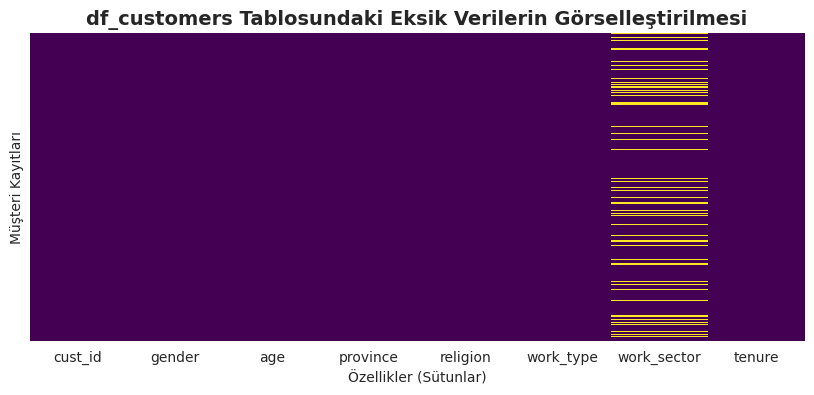


--- 'df_customers' Eksik Veri Raporu ---
             Eksik Kayıt Sayısı  Yüzdelik Oran (%)
work_sector               30134              17.09

--- 'df_history' Eksik Veri Raporu ---
                        Eksik Kayıt Sayısı  Yüzdelik Oran (%)
cc_transaction_all_amt              166746               3.11
cc_transaction_all_cnt              166746               3.11
mobile_eft_all_cnt                  112334               2.10
mobile_eft_all_amt                  112334               2.10

--- 'df_ref_train' Eksik Veri Raporu ---
-> Bu DataFrame'de eksik veri bulunmamaktadır.


In [2]:
# --- BÖLÜM 2: VERİ YÜKLEME VE İLK DEĞERLENDİRME ---

# Ham veri dosyalarını yüklüyoruz (Orijinal yollar korundu)
df_customers = pd.read_csv('/kaggle/input/ing-hubs-turkiye-datathon/customers.csv')
df_history = pd.read_csv('/kaggle/input/ing-hubs-turkiye-datathon/customer_history.csv')
df_ref_train = pd.read_csv('/kaggle/input/ing-hubs-turkiye-datathon/referance_data.csv')


# --- 2.1. Yüklenen Verilerin Yapısal Kontrolü ---
# Her bir DataFrame'in boyutlarını ve ilk kayıtlarını (head) inceliyoruz.

print("--- Veri Yükleme ve Yapısal Kontrol ---")

print(f"\n[1] Müşteri Bilgileri (df_customers)")
print(f"  Boyut: {df_customers.shape}")
print(df_customers.head())

print(f"\n[2] İşlem Geçmişi (df_history)")
print(f"  Boyut: {df_history.shape}")
print(df_history.head())

print(f"\n[3] Churn Etiketleri (df_ref_train)")
print(f"  Boyut: {df_ref_train.shape}")
print(df_ref_train.head())


# --- 2.2. Eksik Veri Haritası (df_customers) ---
# 'df_customers' tablosundaki eksik verilerin yapısını ve yoğunluğunu görsel olarak analiz ediyoruz.
# Bu heatmap, eksikliklerin rastgele mi yoksa belirli sütunlarda mı kümelendiğini gösterir.

plt.figure(figsize=(10, 4))
# yticklabels=False: Y eksenindeki binlerce satır etiketini gizler (okunabilirlik için).
sns.heatmap(df_customers.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('df_customers Tablosundaki Eksik Verilerin Görselleştirilmesi', fontsize=14, fontweight='bold')
plt.xlabel('Özellikler (Sütunlar)')
plt.ylabel('Müşteri Kayıtları')
plt.show()


# --- 2.3. [EKSTRA] Sayısal Eksik Veri Raporu ---
# Görsel analize ek olarak, tüm tablolardaki eksik verilerin sütun bazlı sayısal dökümünü ve yüzdelik oranlarını hesaplıyoruz.
# Bu, veri temizleme stratejisini belirlemek için kritik öneme sahiptir.

def create_missing_summary(df, df_name):
    """
    Verilen DataFrame için sütun bazlı eksik veri raporu oluşturur.
    Yalnızca eksik veri içeren sütunları listeler.
    """
    missing_counts = df.isnull().sum()
    missing_cols = missing_counts[missing_counts > 0] # Sadece eksik veri olanları seç
    
    if missing_cols.empty:
        print(f"\n--- '{df_name}' Eksik Veri Raporu ---")
        print("-> Bu DataFrame'de eksik veri bulunmamaktadır.")
        return

    missing_percentage = (missing_cols / len(df)) * 100
    
    missing_df = pd.DataFrame({
        'Eksik Kayıt Sayısı': missing_cols,
        'Yüzdelik Oran (%)': missing_percentage
    }).sort_values(by='Yüzdelik Oran (%)', ascending=False)
    
    print(f"\n--- '{df_name}' Eksik Veri Raporu ---")
    print(missing_df)

# Tüm veri çerçeveleri için raporları çalıştıralım
create_missing_summary(df_customers, "df_customers")
create_missing_summary(df_history, "df_history")
create_missing_summary(df_ref_train, "df_ref_train")

In [5]:
# --- BÖLÜM 3: NİHAİ ÖZELLİK MÜHENDİSLİĞİ VE ABT OLUŞTURMA ---

# Bu bölümde, ham verileri birleştirip, model için genel, trend (yakınlık) ve ORAN özellikleri türetiyoruz. Bu, projedeki en kritik özellik mühendisliği adımıdır.

print("--- Bölüm 3: Özellik Mühendisliği Başlatıldı ---")

# --- 3.1. Tarih (Datetime) Dönüşümü ---
# Özellik mühendisliğinde (örn: son 3 ay hesabı) ve veri sızıntısını önlemede kullanılmak üzere tarih sütunlarını datetime objelerine dönüştürüyoruz.

df_history['date'] = pd.to_datetime(df_history['date'], format='%Y-%m-%d')
df_ref_train['ref_date'] = pd.to_datetime(df_ref_train['ref_date'], format='%Y-%m-%d')

print("Tarih formatları (df_history['date'] ve df_ref_train['ref_date']) başarıyla dönüştürüldü.")


# --- 3.2. Nihai Özellik Fonksiyonu ---

def create_final_features(df_labels, df_history, df_customers):
    """
    Verilen etiketler için demografik, davranışsal, trend ve oran özelliklerini oluşturan nihai fonksiyondur.
    """
    
    # 1. Veri Sızıntısını Önleme (Time-aware Merge)
    df_history_merged = pd.merge(df_history, df_labels[['cust_id', 'ref_date']], on='cust_id', how='inner')
    features_df = df_history_merged[df_history_merged['date'] < df_history_merged['ref_date']].copy()

    # 2. Genel Davranış Özellikleri (Aggregations)
    agg_dict = {
        'mobile_eft_all_cnt': ['mean', 'sum', 'std', 'max'],
        'active_product_category_nbr': ['mean', 'max'],
        'mobile_eft_all_amt': ['mean', 'sum', 'std', 'max'],
        'cc_transaction_all_amt': ['mean', 'sum', 'std', 'max'],
        'cc_transaction_all_cnt': ['mean', 'sum', 'std', 'max'],
        'date': ['count'] # Toplam kaç ay işlem yaptığı (month_count_total)
    }
    
    customer_features = features_df.groupby('cust_id').agg(agg_dict)
    customer_features.columns = ['_'.join(col).strip() for col in customer_features.columns.values]
    customer_features.rename(columns={'date_count': 'month_count_total'}, inplace=True)
    
    # 3. Trend/Yakınlık Özellikleri (Son 3 Ay)
    features_df['month_diff'] = (features_df['ref_date'].dt.year - features_df['date'].dt.year) * 12 + \
                                (features_df['ref_date'].dt.month - features_df['date'].dt.month)
    
    last_3_months_df = features_df[features_df['month_diff'] <= 3]
    features_last_3m = last_3_months_df.groupby('cust_id').agg({
        'cc_transaction_all_amt': ['sum'], 
        'mobile_eft_all_cnt': ['sum']
    })
    features_last_3m.columns = ['_'.join(col).strip() + '_last3m' for col in features_last_3m.columns.values]

    # 4. Tüm Özellikleri ve Ana Tabloları Birleştirme
    final_df = pd.merge(df_labels, df_customers, on='cust_id', how='left')
    final_df = pd.merge(final_df, customer_features, on='cust_id', how='left')
    final_df = pd.merge(final_df, features_last_3m, on='cust_id', how='left')
    
    # 5. YENİ NİHAİ ADIM: ORAN ÖZELLİKLERİ
    # Müşterinin yakın dönem davranışının, genel davranışına oranı. (Churn tahmininde güçlü sinyallerdir)
    
    # Sıfıra bölme hatasını engellemek için küçük bir sayı (1e-6) ekliyoruz.
    final_df['cc_amt_ratio_last3m_vs_total'] = \
        final_df['cc_transaction_all_amt_sum_last3m'] / (final_df['cc_transaction_all_amt_sum'] + 1e-6)
        
    final_df['eft_cnt_ratio_last3m_vs_total'] = \
        final_df['mobile_eft_all_cnt_sum_last3m'] / (final_df['mobile_eft_all_cnt_sum'] + 1e-6)

    # 6. Temizlik
    final_df.replace([np.inf, -np.inf], np.nan, inplace=True)
    final_df.fillna(0, inplace=True)
    
    print("Genel, Trend ve Oran özellikleri başarıyla birleştirildi.")
    return final_df

# --- 3.3. Gelişmiş ABT'yi Oluşturma ---
print("\n--- 3.3. Nihai Analitik Temel Tablo (ABT) oluşturuluyor... ---")
df_final = create_final_features(df_ref_train, df_history, df_customers)

print(f"\nNihai ABT (df_final) başarıyla oluşturuldu!")
print(f"Yeni ABT Boyutu (Satır, Sütun): {df_final.shape}")
print("Yeni eklenen 'Oran Özellikleri':")
print([col for col in df_final.columns if '_ratio' in col])

--- Bölüm 3: Özellik Mühendisliği Başlatıldı ---
Tarih formatları (df_history['date'] ve df_ref_train['ref_date']) başarıyla dönüştürüldü.

--- 3.3. Nihai Analitik Temel Tablo (ABT) oluşturuluyor... ---
Genel, Trend ve Oran özellikleri başarıyla birleştirildi.

Nihai ABT (df_final) başarıyla oluşturuldu!
Yeni ABT Boyutu (Satır, Sütun): (133287, 33)
Yeni eklenen 'Oran Özellikleri':
['cc_amt_ratio_last3m_vs_total', 'eft_cnt_ratio_last3m_vs_total']



 BÖLÜM 4.1: HEDEF DEĞİŞKEN ANALİZİ (CHURN)
Kayıp (Churn) Durumu (Sayısal):
churn
0    114417
1     18870
Name: count, dtype: int64

Kayıp (Churn) Durumu (Yüzdesel):
churn
0   85.84
1   14.16
Name: proportion, dtype: float64


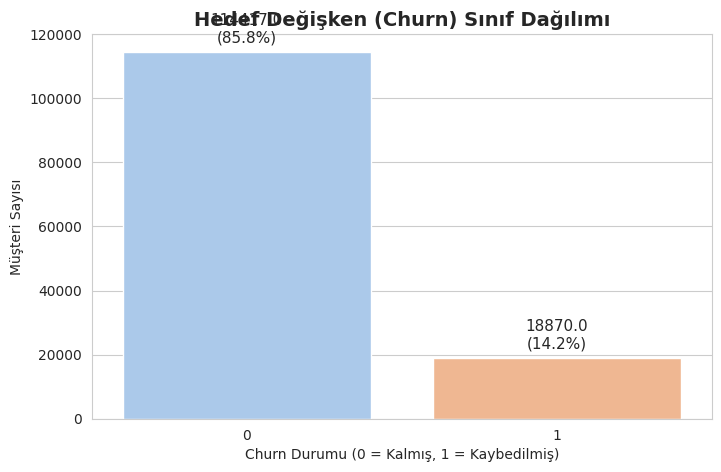


METODOLOJİK NOT: Hedef değişken 'dengesiz' (imbalanced) görünüyor.
-> Azınlık sınıfı (muhtemelen '1') toplam verinin %20'sinden azını oluşturuyor.
-> Model eğitiminde (Bölüm 8) 'scale_pos_weight' parametresini kullanma kararımız hala %100 geçerli ve kritiktir.


In [10]:
# --- 4.1. Hedef Değişken Analizi (churn) ---

# Modellemeye başlamadan önce, hedef değişkenin ('churn') dağılımını (sınıf dengesini)
# incelemek, model seçimi ve değerlendirme metrikleri için kritik öneme sahiptir.

print("\n" + "="*50)
print(" BÖLÜM 4.1: HEDEF DEĞİŞKEN ANALİZİ (CHURN)")
print("="*50)

# Sayısal ve yüzdesel dağılımı hesaplayalım
churn_counts = df_final['churn'].value_counts()
churn_percentage = df_final['churn'].value_counts(normalize=True) * 100

print("Kayıp (Churn) Durumu (Sayısal):")
print(churn_counts)
print("\nKayıp (Churn) Durumu (Yüzdesel):")
print(churn_percentage.round(2))

# --- 4.1.1. Hedef Değişken Görselleştirmesi ---

plt.figure(figsize=(8, 5))
ax = sns.countplot(x='churn', data=df_final, palette='pastel')

plt.title('Hedef Değişken (Churn) Sınıf Dağılımı', fontsize=14, fontweight='bold')
plt.xlabel('Churn Durumu (0 = Kalmış, 1 = Kaybedilmiş)')
plt.ylabel('Müşteri Sayısı')

# Çubukların üzerine yüzdeleri ve sayıları ekleyelim (daha zengin bir gösterim)
total_len = len(df_final)
for p in ax.patches:
    height = p.get_height()
    percentage = '{:.1f}%'.format(100 * height / total_len)
    label = f"{height}\n({percentage})" # Hem sayı hem yüzde
    
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    
    ax.annotate(label, (x, y), ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontsize=11)

plt.show()

# --- 4.1.2. Metodolojik Yorum (Dengesiz Veri Tespiti) ---
# Sınıf dağılımına göre modelleme stratejisi belirleme

# Azınlık sınıfının yüzdesini alalım
try:
    min_class_percentage = churn_percentage.min()
except (AttributeError, ValueError):
    print("\nMETODOLOJİK NOT: Churn yüzdesi hesaplanamadı. Veri yüklenmemiş olabilir.")
    min_class_percentage = 50 # Hata durumunda dengeli varsay

if min_class_percentage < 20: # Eğer bir sınıf %20'den azsa
    print("\nMETODOLOJİK NOT: Hedef değişken 'dengesiz' (imbalanced) görünüyor.")
    print("-> Azınlık sınıfı (muhtemelen '1') toplam verinin %20'sinden azını oluşturuyor.")
    print("-> Model eğitiminde (Bölüm 8) 'scale_pos_weight' parametresini kullanma kararımız hala %100 geçerli ve kritiktir.")
else:
    print("\nMETODOLOJİK NOT: Hedef değişken sınıfları 'dengeli' görünüyor.")
    print("-> Sınıflar arasında ciddi bir dengesizlik gözlemlenmedi.")


--- 4.2.1. Veri Yapısı ve Bellek Kullanımı (info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133287 entries, 0 to 133286
Data columns (total 33 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   cust_id                            133287 non-null  int64         
 1   ref_date                           133287 non-null  datetime64[ns]
 2   churn                              133287 non-null  int64         
 3   gender                             133287 non-null  object        
 4   age                                133287 non-null  int64         
 5   province                           133287 non-null  object        
 6   religion                           133287 non-null  object        
 7   work_type                          133287 non-null  object        
 8   work_sector                        133287 non-null  object        
 9   tenure                             13

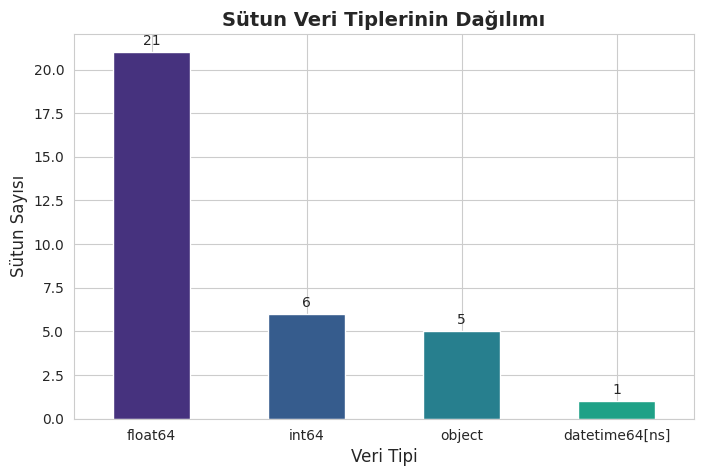

In [11]:
# --- 4.2. Veri Yapısı ve İstatistiksel Özet ---
# Bölüm 3  ile oluşturduğumuz yeni 'df_final' tablomuza ve yeni eklenen özelliklere (..._ratio, ..._last3m, ..._std) yakından bakıyoruz.

print("\n--- 4.2.1. Veri Yapısı ve Bellek Kullanımı (info) ---")
# Bu, 'df_final'deki son sütun listemizi, veri tiplerini (object, float vb.)
# ve eksik veri olmadığını (Bölüm 3.2 - fillna(0) sayesinde) teyit eder.
# Sütun sayısının (Column count) arttığını görmeliyiz.
df_final.info()


print("\n\n--- 4.2.2. Sayısal Sütunların İstatistiksel Özeti (describe) ---")
# 'min', 'max', 'mean' ve 'std' değerlerine bakıyoruz.
# Bu, özellikle yeni '..._ratio' özelliklerimizin ölçeğini (0-1 arası mı?)
# ve '..._sum' özelliklerindeki potansiyel aykırı değerleri (yüksek 'max')
# tespit etmek için önemlidir.
print(df_final.describe())


print("\n\n--- 4.2.3. Sütun Veri Tiplerinin Görsel Dökümü ---")
# Ön işleme (Bölüm 7) için ne kadar işimiz olduğunu görelim:
# (Kaç 'object' -> get_dummies? Kaç 'float/int' -> StandardScaler?)
plt.figure(figsize=(8, 5))
ax = df_final.dtypes.value_counts().plot(kind='bar', color=sns.color_palette("viridis"))
ax.bar_label(ax.containers[0], padding=3)
plt.title('Sütun Veri Tiplerinin Dağılımı', fontsize=14, fontweight='bold')
plt.xlabel('Veri Tipi', fontsize=12)
plt.ylabel('Sütun Sayısı', fontsize=12)
plt.xticks(rotation=0)
plt.show()


--- 4.3.1. Anahtar Sayısal Özelliklerin Dağılım (Histogram) Analizi ---


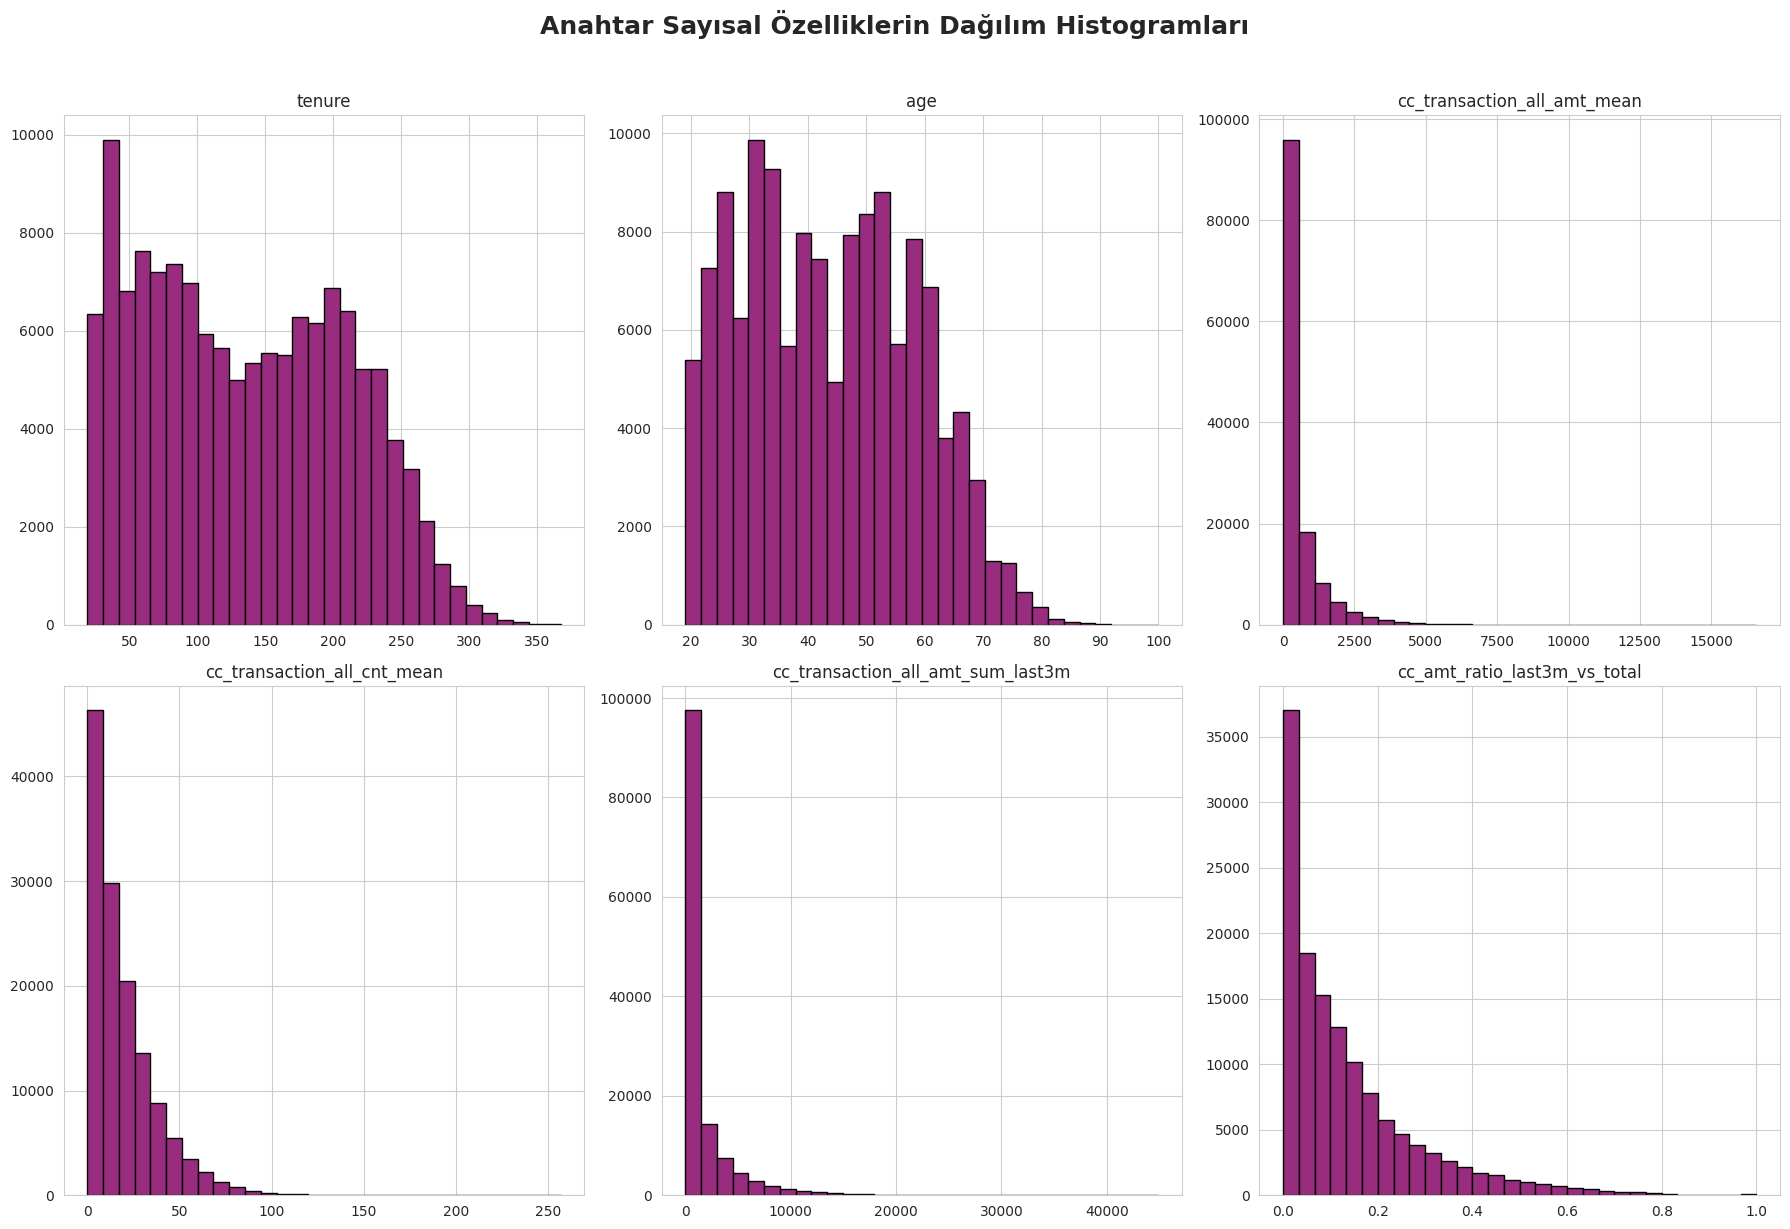


METODOLOJİK NOT (Histogram): Harcama ve Oran metrikleri ('..._ratio' vb.) 'sağa çarpık'.
-> Bölüm 7'de (Ön İşleme) 'StandardScaler' kullanma kararımız hala geçerlidir.

--- 4.3.2. Anahtar Sayısal Özelliklerin Churn'e Göre Analizi (KDE Plot) ---


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated a

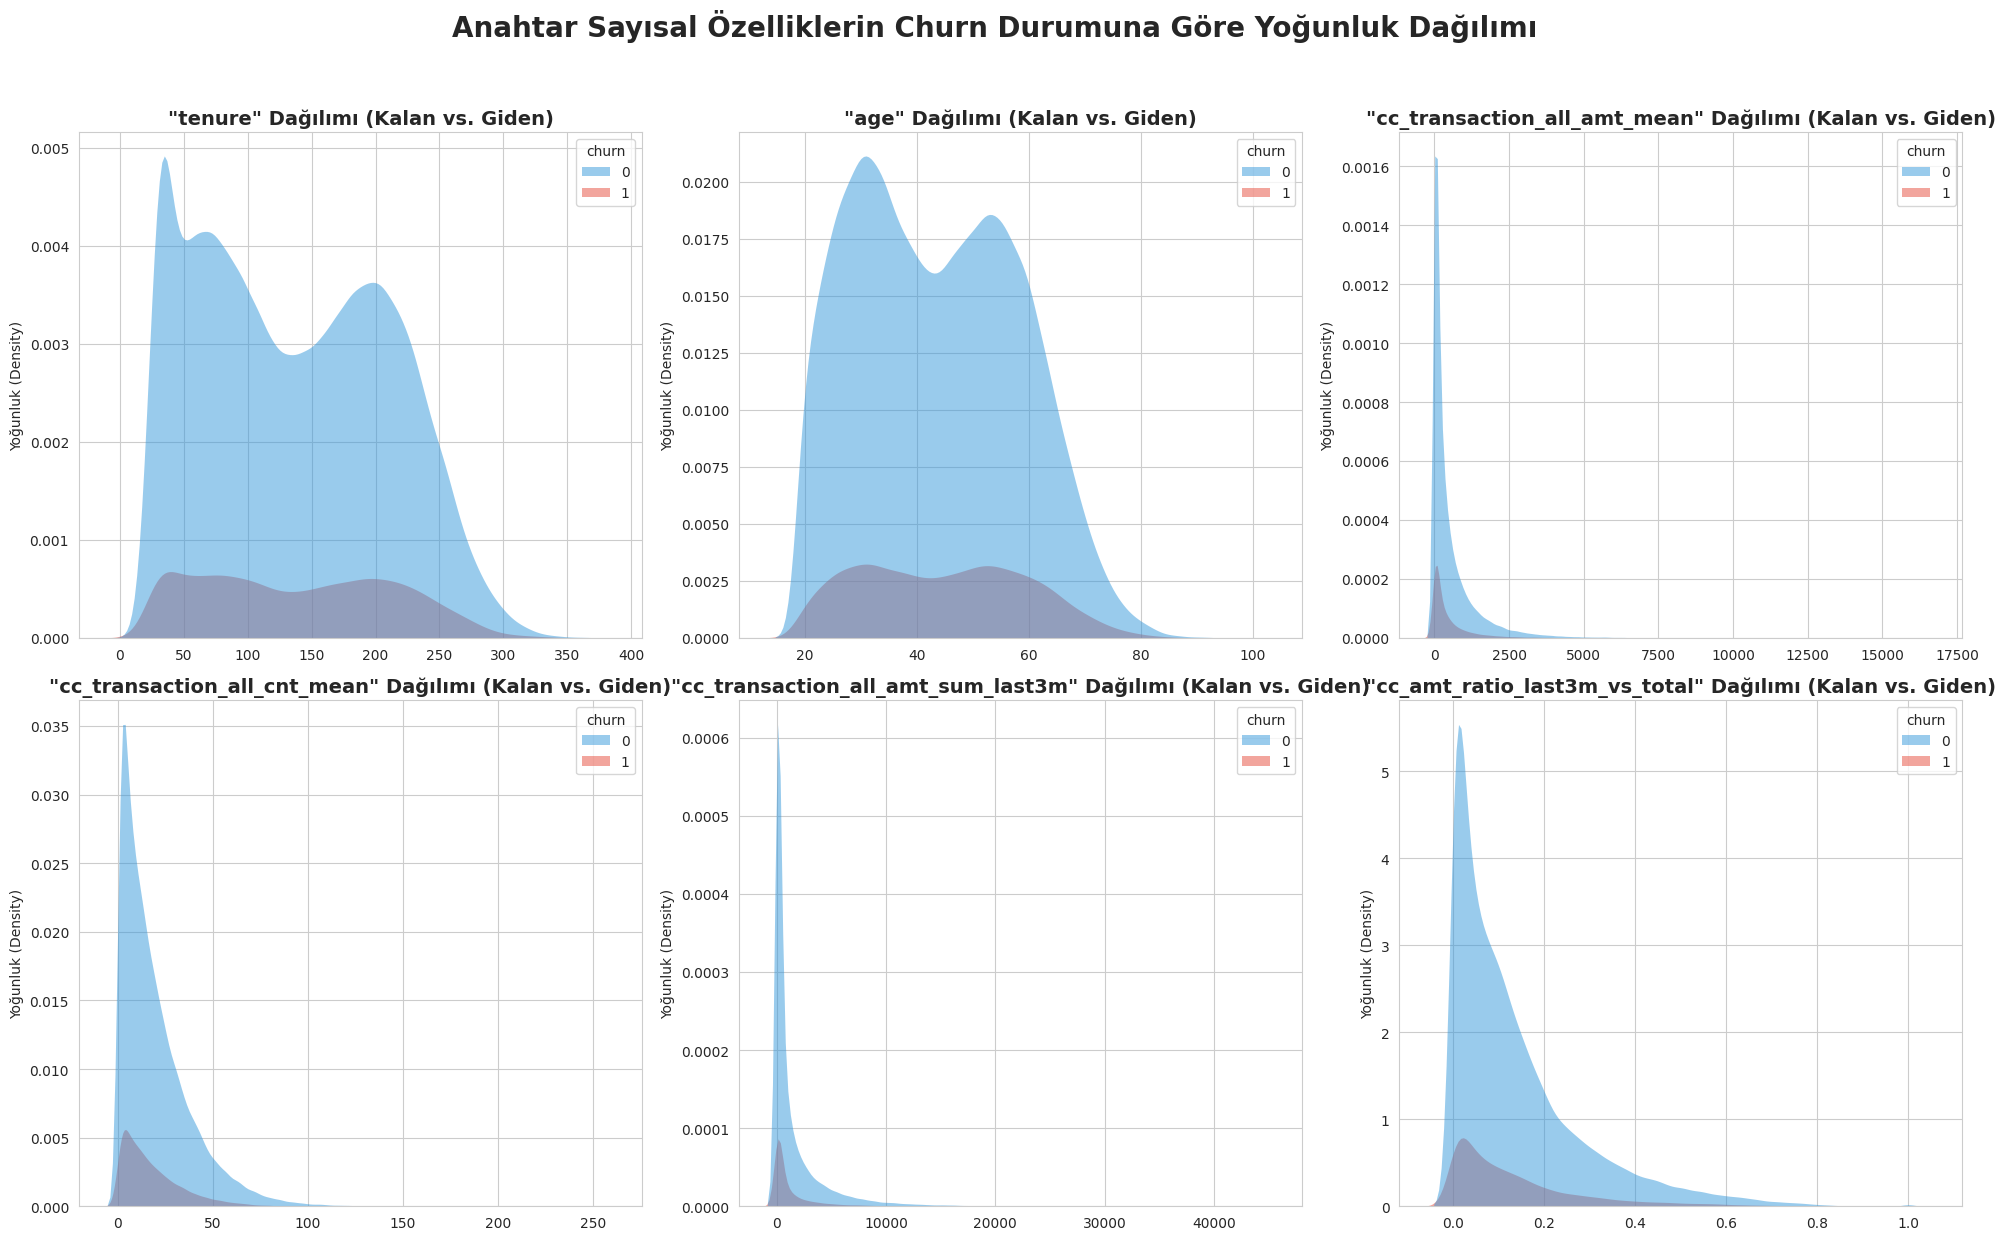

In [12]:
# --- 4.3. Sayısal Özelliklerin Dağılım ve Churn Analizi ---

# Yeni ABT'miz üzerinde analiz etmek için hem eski (temel) hem de yeni (trend, oran) özelliklerden oluşan bir "anahtar özellikler" listesi tanımlıyoruz.
key_numerical_features = [
    # Demografik
    'tenure', 
    'age',
    
    # Genel Davranış (Ortalamalar)
    'cc_transaction_all_amt_mean',  # Ortalama KK Harcaması
    'cc_transaction_all_cnt_mean',  # Ortalama KK İşlem Sayısı
    
    # Yeni Trend Özelliği (Son 3 Ay)
    'cc_transaction_all_amt_sum_last3m', # Son 3 Aydaki Toplam Harcama
    
    # Yeni Oran Özelliği (En Kritik)
    'cc_amt_ratio_last3m_vs_total' # Son 3 Ay Harcamasının Toplama Oranı
]

# --- 4.3.1. Univariate Analiz: Dağılım Histogramları ---
print("\n--- 4.3.1. Anahtar Sayısal Özelliklerin Dağılım (Histogram) Analizi ---")

# 'key_numerical_features' listesindeki özelliklerin varlığını kontrol et
valid_hist_features = [col for col in key_numerical_features if col in df_final.columns]

if valid_hist_features:
    df_final[valid_hist_features].hist(
        bins=30, 
        figsize=(18, 12), 
        layout=(-1, 3), 
        color=sns.color_palette("magma")[2],
        edgecolor='black'
    )
    plt.suptitle('Anahtar Sayısal Özelliklerin Dağılım Histogramları', y=1.02, fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\nMETODOLOJİK NOT (Histogram): Harcama ve Oran metrikleri ('..._ratio' vb.) 'sağa çarpık'.")
    print("-> Bölüm 7'de (Ön İşleme) 'StandardScaler' kullanma kararımız hala geçerlidir.")
else:
    print("UYARI: Histogram için seçilen anahtar özellikler 'df_final' tablosunda bulunamadı.")


# --- 4.3.2. Bivariate Analiz: Churn'e Göre Yoğunluk (KDE) ---
print("\n--- 4.3.2. Anahtar Sayısal Özelliklerin Churn'e Göre Analizi (KDE Plot) ---")

# 'key_numerical_features' listesindeki özelliklerin varlığını kontrol et
valid_kde_features = [col for col in key_numerical_features if col in df_final.columns and col != 'churn']

if valid_kde_features:
    # Grafik ızgarasını oluşturalım
    num_features = len(valid_kde_features)
    nrows = int(np.ceil(num_features / 3))
    fig, axes = plt.subplots(nrows=nrows, ncols=3, figsize=(20, nrows * 6))
    axes = axes.flatten() 
    palette = {0: '#3498db', 1: '#e74c3c'} # Kalan (Mavi), Giden (Kırmızı)

    for i, col in enumerate(valid_kde_features):
        ax = axes[i]
        try:
            sns.kdeplot(
                data=df_final, 
                x=col, 
                hue='churn',
                fill=True,
                alpha=0.5,
                palette=palette,
                ax=ax,
                linewidth=0,
                # Çok çarpık veriler (örn: oranlar) için log ölçeği daha iyi olabilir
                log_scale=False 
            )
            ax.set_title(f'"{col}" Dağılımı (Kalan vs. Giden)', fontsize=14, fontweight='bold')
            ax.set_xlabel('')
            ax.set_ylabel('Yoğunluk (Density)')

            handles, labels = ax.get_legend_handles_labels()
            if handles: # Legend'ı sadece oluştuysa ayarla
                ax.legend(handles, ['Kalan Müşteri (0)', 'Giden Müşteri (1)'], title='Durum')
        except Exception as e:
            ax.set_title(f'"{col}" çizilemedi: {e}', color='red')

    # Kullanılmayan alt grafikleri gizle
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle('Anahtar Sayısal Özelliklerin Churn Durumuna Göre Yoğunluk Dağılımı', y=1.03, fontsize=20, fontweight='bold')
    plt.tight_layout()
    plt.show()


--- 4.4. Sayısal Özelliklerin Churn'e Göre Analizi (Logaritmik Ölçek) ---


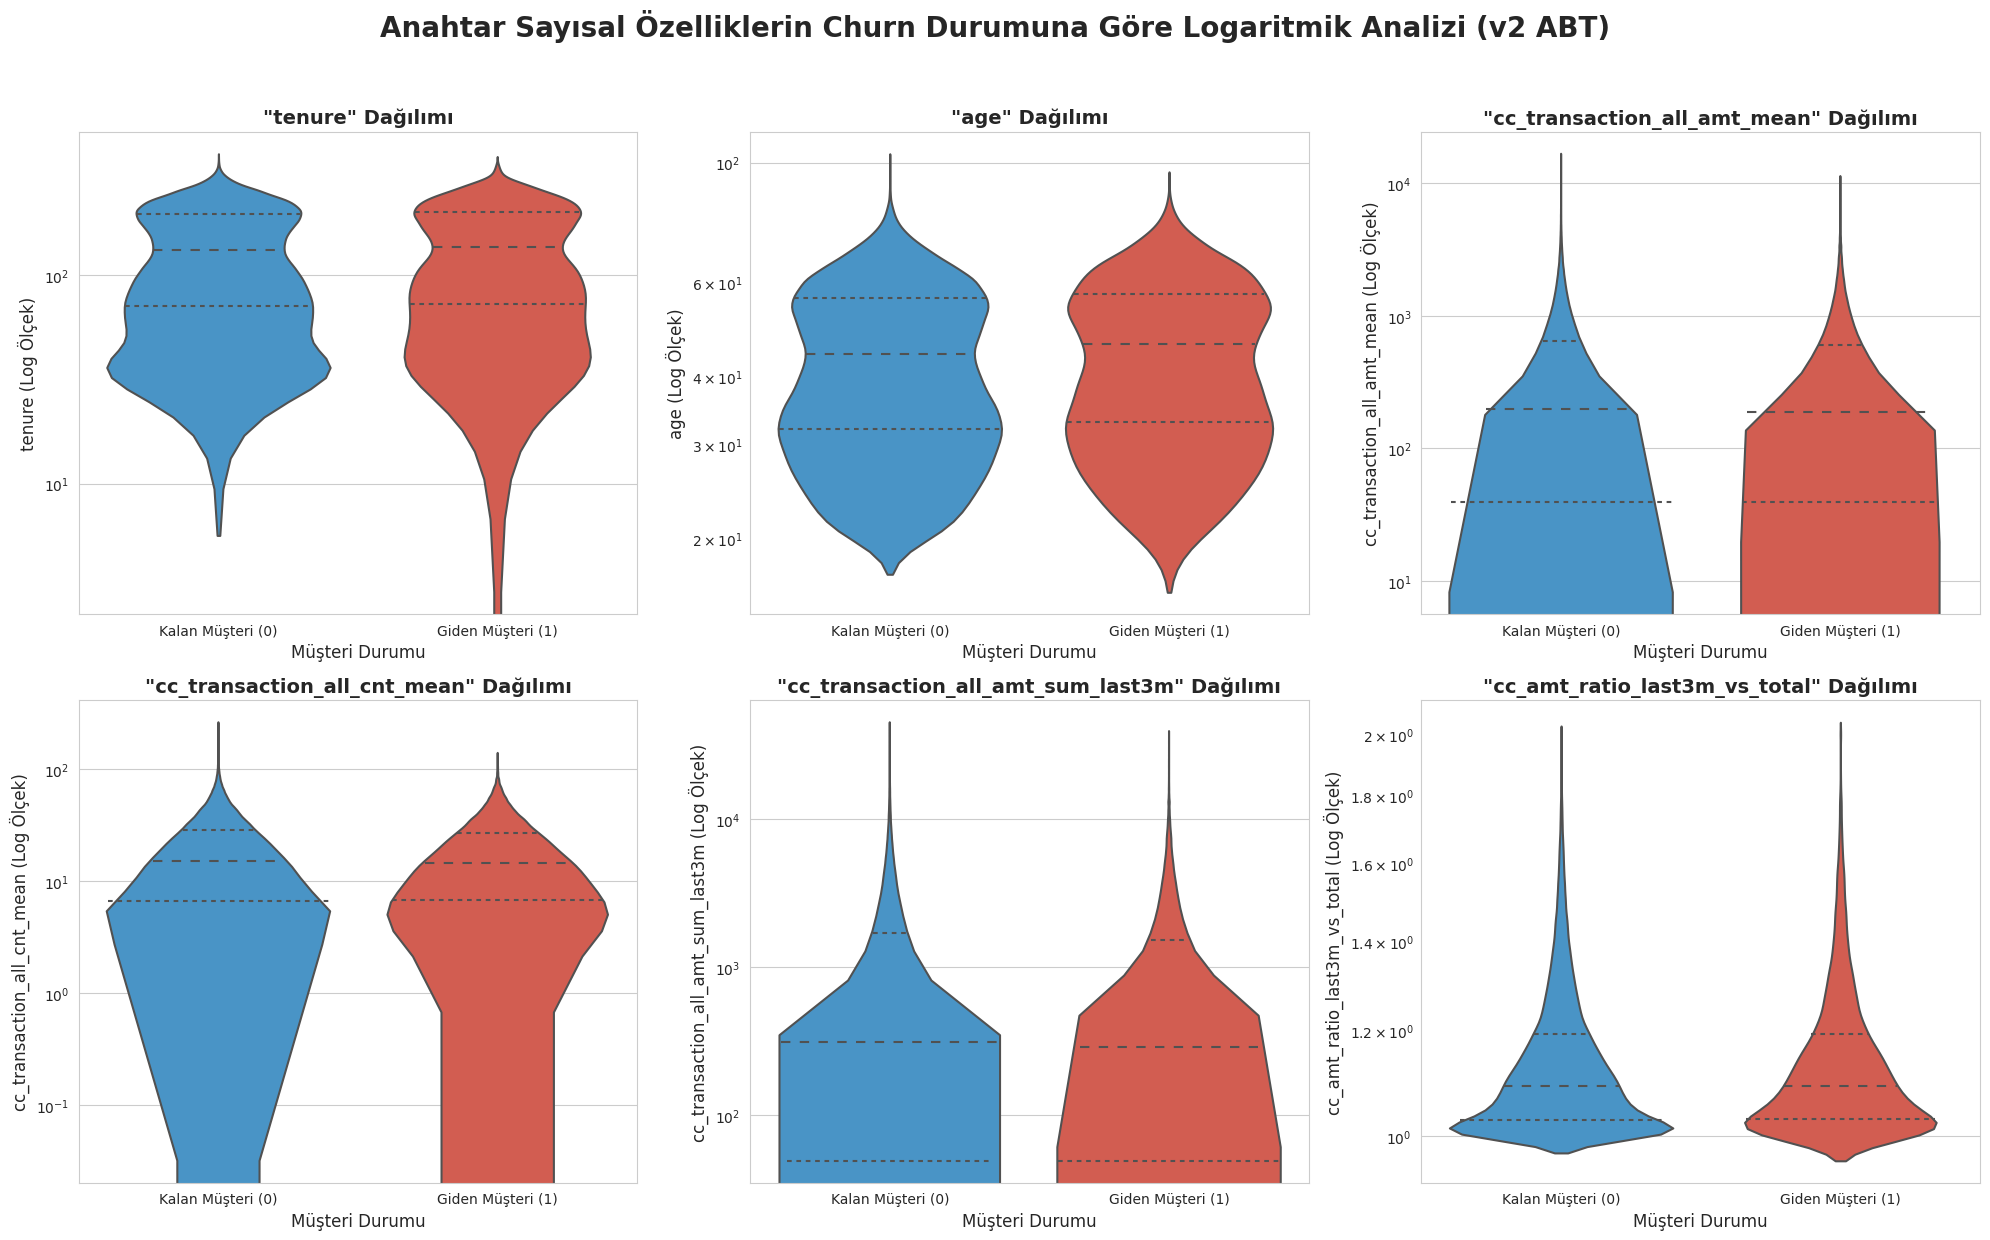


METODOLOJİK NOT (Violin Plot):
-> Bu grafikler, Kalan (0) ve Giden (1) gruplarının medyanlarını (ortadaki çizgi) ve dağılım şekillerini ('şişkinlik') daha adil karşılaştırmamızı sağlar.
-> Özellikle '{'cc_amt_ratio_last3m_vs_total'}' gibi yeni özelliklerdeki ayrışmanın ne kadar net olduğuna dikkat edin.


In [15]:
# --- 4.4. Sayısal Özellikler ve Churn (Logaritmik Ölçekli Keman Grafikleri) ---

# Bölüm 4.3'te tespit edilen aşırı sağa çarpıklık (skewness) sorununu ele almak ve aykırı değerlerin (outliers) analizi bozmasını engellemek için Logaritmik Ölçekli Keman Grafikleri (Violin Plots) kullanıyoruz.

print("\n--- 4.4. Sayısal Özelliklerin Churn'e Göre Analizi (Logaritmik Ölçek) ---")

# Bir önceki adımda (4.3) tanımladığımız 'key_numerical_features' listesini ve bu özelliklerin varlık kontrolünü tekrar kullanalım.
try:
    # 'key_numerical_features' listesinden sadece df_final'de olanları al
    valid_violin_features = [col for col in key_numerical_features if col in df_final.columns and col != 'churn']
except NameError:
    # Eğer 'key_numerical_features' bir önceki hücreden gelmediyse, manuel olarak tanımla
    valid_violin_features = [
        'tenure', 'age', 'cc_transaction_all_amt_mean', 'cc_transaction_all_cnt_mean',
        'cc_transaction_all_amt_sum_last3m', 'cc_amt_ratio_last3m_vs_total'
    ]
    valid_violin_features = [col for col in valid_violin_features if col in df_final.columns]


if valid_violin_features:
    # Grafik ızgarasını oluşturalım
    num_features = len(valid_violin_features)
    nrows = int(np.ceil(num_features / 3))
    fig, axes = plt.subplots(nrows=nrows, ncols=3, figsize=(20, nrows * 6))
    axes = axes.flatten() 
    palette = {0: '#3498db', 1: '#e74c3c'} # Kalan (Mavi), Giden (Kırmızı)

    for i, feature in enumerate(valid_violin_features):
        ax = axes[i]
        
        # --- Violinplot (Logaritmik Ölçek ile) ---
        # DİKKAT: y eksenine logaritmik ölçek uygulayacağımız için, 0 değerlerinden kaçınmak amacıyla (log(0) tanımsızdır) y eksenine +1 ekliyoruz.
        try:
            sns.violinplot(
                x='churn',
                y=df_final[feature] + 1,  # Log(0) hatasını önlemek için +1
                data=df_final,
                ax=ax,
                palette=palette,
                inner='quartile' # Kemanın içine çeyreklikleri (median vb.) çiz
            )
            
            # Y eksenini logaritmik ölçeğe ayarlıyoruz.
            ax.set_yscale('log')
            
            ax.set_title(f'"{feature}" Dağılımı', fontsize=14, fontweight='bold')
            ax.set_xticklabels(['Kalan Müşteri (0)', 'Giden Müşteri (1)'])
            ax.set_ylabel(f'{feature} (Log Ölçek)', fontsize=12)
            ax.set_xlabel('Müşteri Durumu', fontsize=12)
        except Exception as e:
            ax.set_title(f'"{feature}" çizilemedi: {e}', color='red')

    # Kullanılmayan alt grafikleri gizle
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    # Tüm figür için ana başlık
    plt.suptitle('Anahtar Sayısal Özelliklerin Churn Durumuna Göre Logaritmik Analizi (v2 ABT)', y=1.03, fontsize=20, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\nMETODOLOJİK NOT (Violin Plot):")
    print("-> Bu grafikler, Kalan (0) ve Giden (1) gruplarının medyanlarını (ortadaki çizgi) ve dağılım şekillerini ('şişkinlik') daha adil karşılaştırmamızı sağlar.")
    print("-> Özellikle '{'cc_amt_ratio_last3m_vs_total'}' gibi yeni özelliklerdeki ayrışmanın ne kadar net olduğuna dikkat edin.")
else:
    print("UYARI: Keman grafiği için seçilen anahtar özellikler 'df_final' tablosunda bulunamadı.")

--- Bölüm 5: Kategorik Özelliklerin Churn Oranlarına Etkisi ---


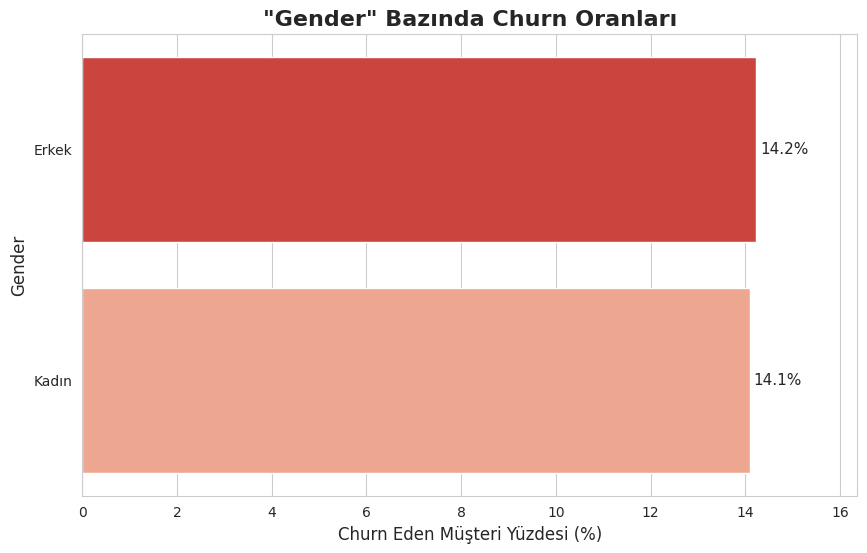

--------------------------------------------------------------------------------


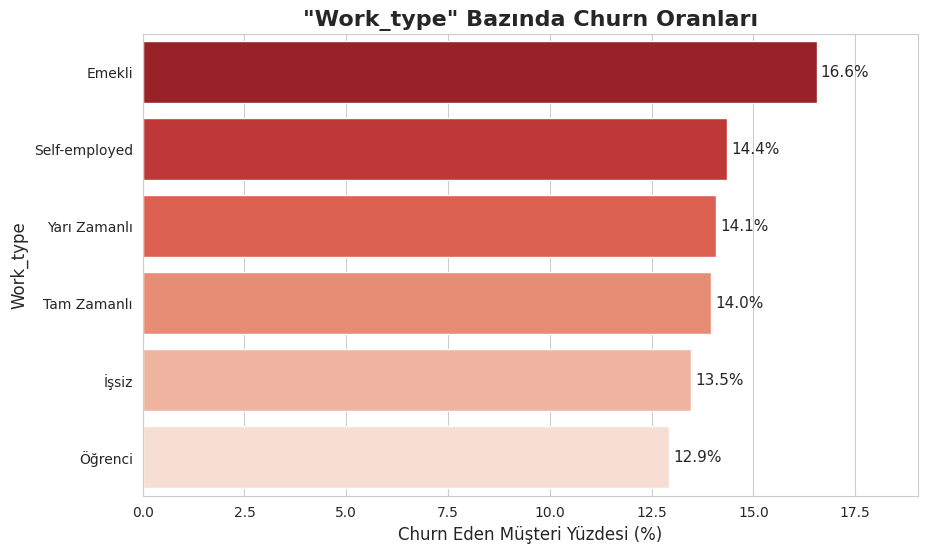

--------------------------------------------------------------------------------

METODOLOJİK NOT: Kategorik analiz tamamlandı.
-> Bu grafikler, hangi segmentlerin (örn: 'İşsiz' veya 'Öğrenci') genel ortalamadan daha yüksek risk taşıdığını net bir şekilde ortaya koyar.


In [16]:
# --- BÖLÜM 5: KATEGORİK ÖZELLİKLERİN ANALİZİ ---

# Bu bölümde, 'gender' (cinsiyet), 'work_type' (çalışma durumu) gibi kategorik özelliklerin 'churn' üzerindeki etkisini inceliyoruz.
# Amaç: Hangi müşteri segmentlerinin (gruplarının) kayıp (churn) riskinin daha yüksek olduğunu tespit etmektir.

print("--- Bölüm 5: Kategorik Özelliklerin Churn Oranlarına Etkisi ---")

# Analiz edeceğimiz kategorik özellikleri tanımlıyoruz.
# NOT: 'province' ve 'work_sector'ı (Bölüm 3'de kullanılan ham sütunlar) burada analiz etmemize gerek yok, çünkü çok fazla kategori (yüksek kardinalite) içeriyorlar ve Bölüm 7'de (Ön İşleme) zaten gruplanacaklar.
categorical_features_to_analyze = [
    'gender',
    'work_type'
]
# 'df_final' tablosunda var olanları filtrele
categorical_features = [col for col in categorical_features_to_analyze if col in df_final.columns]


# Grafik etiketleri için "Tercüme Sözlüğü"
label_maps = {
    'gender': {'F': 'Kadın', 'M': 'Erkek'},
    'work_type': {
        'Full-time': 'Tam Zamanlı',
        'Part-time': 'Yarı Zamanlı',
        'Unemployed': 'İşsiz',
        'Student': 'Öğrenci',
        'Retired': 'Emekli',
        'Bilinmiyor': 'Bilinmiyor' # (Eğer Bölüm 3'te böyle bir temizlik yaptıysak)
    }
}


if not categorical_features:
    print("UYARI: Analiz için tanımlanan kategorik özellikler ('gender', 'work_type') 'df_final' tablosunda bulunamadı.")
else:
    for feature in categorical_features:
        
        # --- Churn Oranı Hesaplaması ---
        # Her bir kategori (örn: 'Full-time') içindeki 'churn' oranını (normalize=True) hesaplıyoruz.
        try:
            # .loc[:,1] ile sadece churn=1 (Giden) olanların yüzdesini seçiyoruz.
            churn_rate = df_final.groupby(feature)['churn'].value_counts(normalize=True).loc[:,1].mul(100).sort_values(ascending=False)
            churn_rate = churn_rate.reset_index(name='percentage')
        except KeyError:
            # Bazı segmentlerde hiç churn (churn=1) olmayabilir.
            print(f"-> UYARI: '{feature}' özelliği için (churn=1) kaydı bulunamadı veya hesaplama hatası. Bu özellik atlanıyor.")
            continue
        except Exception as e:
            print(f"-> HATA: '{feature}' özelliği hesaplanırken hata oluştu: {e}. Atlanıyor.")
            continue

        # --- TERCÜME ADIMI ---
        # Grafik etiketlerini (y ekseni) daha anlaşılır hale getiriyoruz.
        if feature in label_maps:
            churn_rate[feature] = churn_rate[feature].map(label_maps[feature]).fillna(churn_rate[feature])

        
        # --- Görselleştirme: Sıralı Bar Grafiği ---
        # En yüksek riskli segmentten en düşüğe doğru sıralanmış net bir bar grafiği çizdiriyoruz.
        plt.figure(figsize=(10, 6))
        ax = sns.barplot(
            data=churn_rate,
            x='percentage',
            y=feature,
            palette='Reds_r' # En yüksek churn'ü en koyu kırmızı yap
        )
        
        # Barların üzerine yüzdesel değerlerini yazdır
        ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3, fontsize=11)
        
        descriptive_name = label_maps.get(feature, {}).get('__title__', feature.capitalize()) # Başlık için (henüz kullanmadık)
        plt.title(f'"{feature.capitalize()}" Bazında Churn Oranları', fontsize=16, fontweight='bold')
        plt.xlabel('Churn Eden Müşteri Yüzdesi (%)', fontsize=12)
        plt.ylabel(feature.capitalize(), fontsize=12)
        
        # X ekseninin limitini, en uzun bara göre %15 daha geniş ayarla
        if not churn_rate.empty:
            plt.xlim(right=churn_rate['percentage'].max() * 1.15)
        
        plt.show()
        
        print("-" * 80)

print("\nMETODOLOJİK NOT: Kategorik analiz tamamlandı.")
print("-> Bu grafikler, hangi segmentlerin (örn: 'İşsiz' veya 'Öğrenci') genel ortalamadan daha yüksek risk taşıdığını net bir şekilde ortaya koyar.")

--- 6.2. Tüm Sayısal Özelliklerin Korelasyon Isı Haritası ---


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


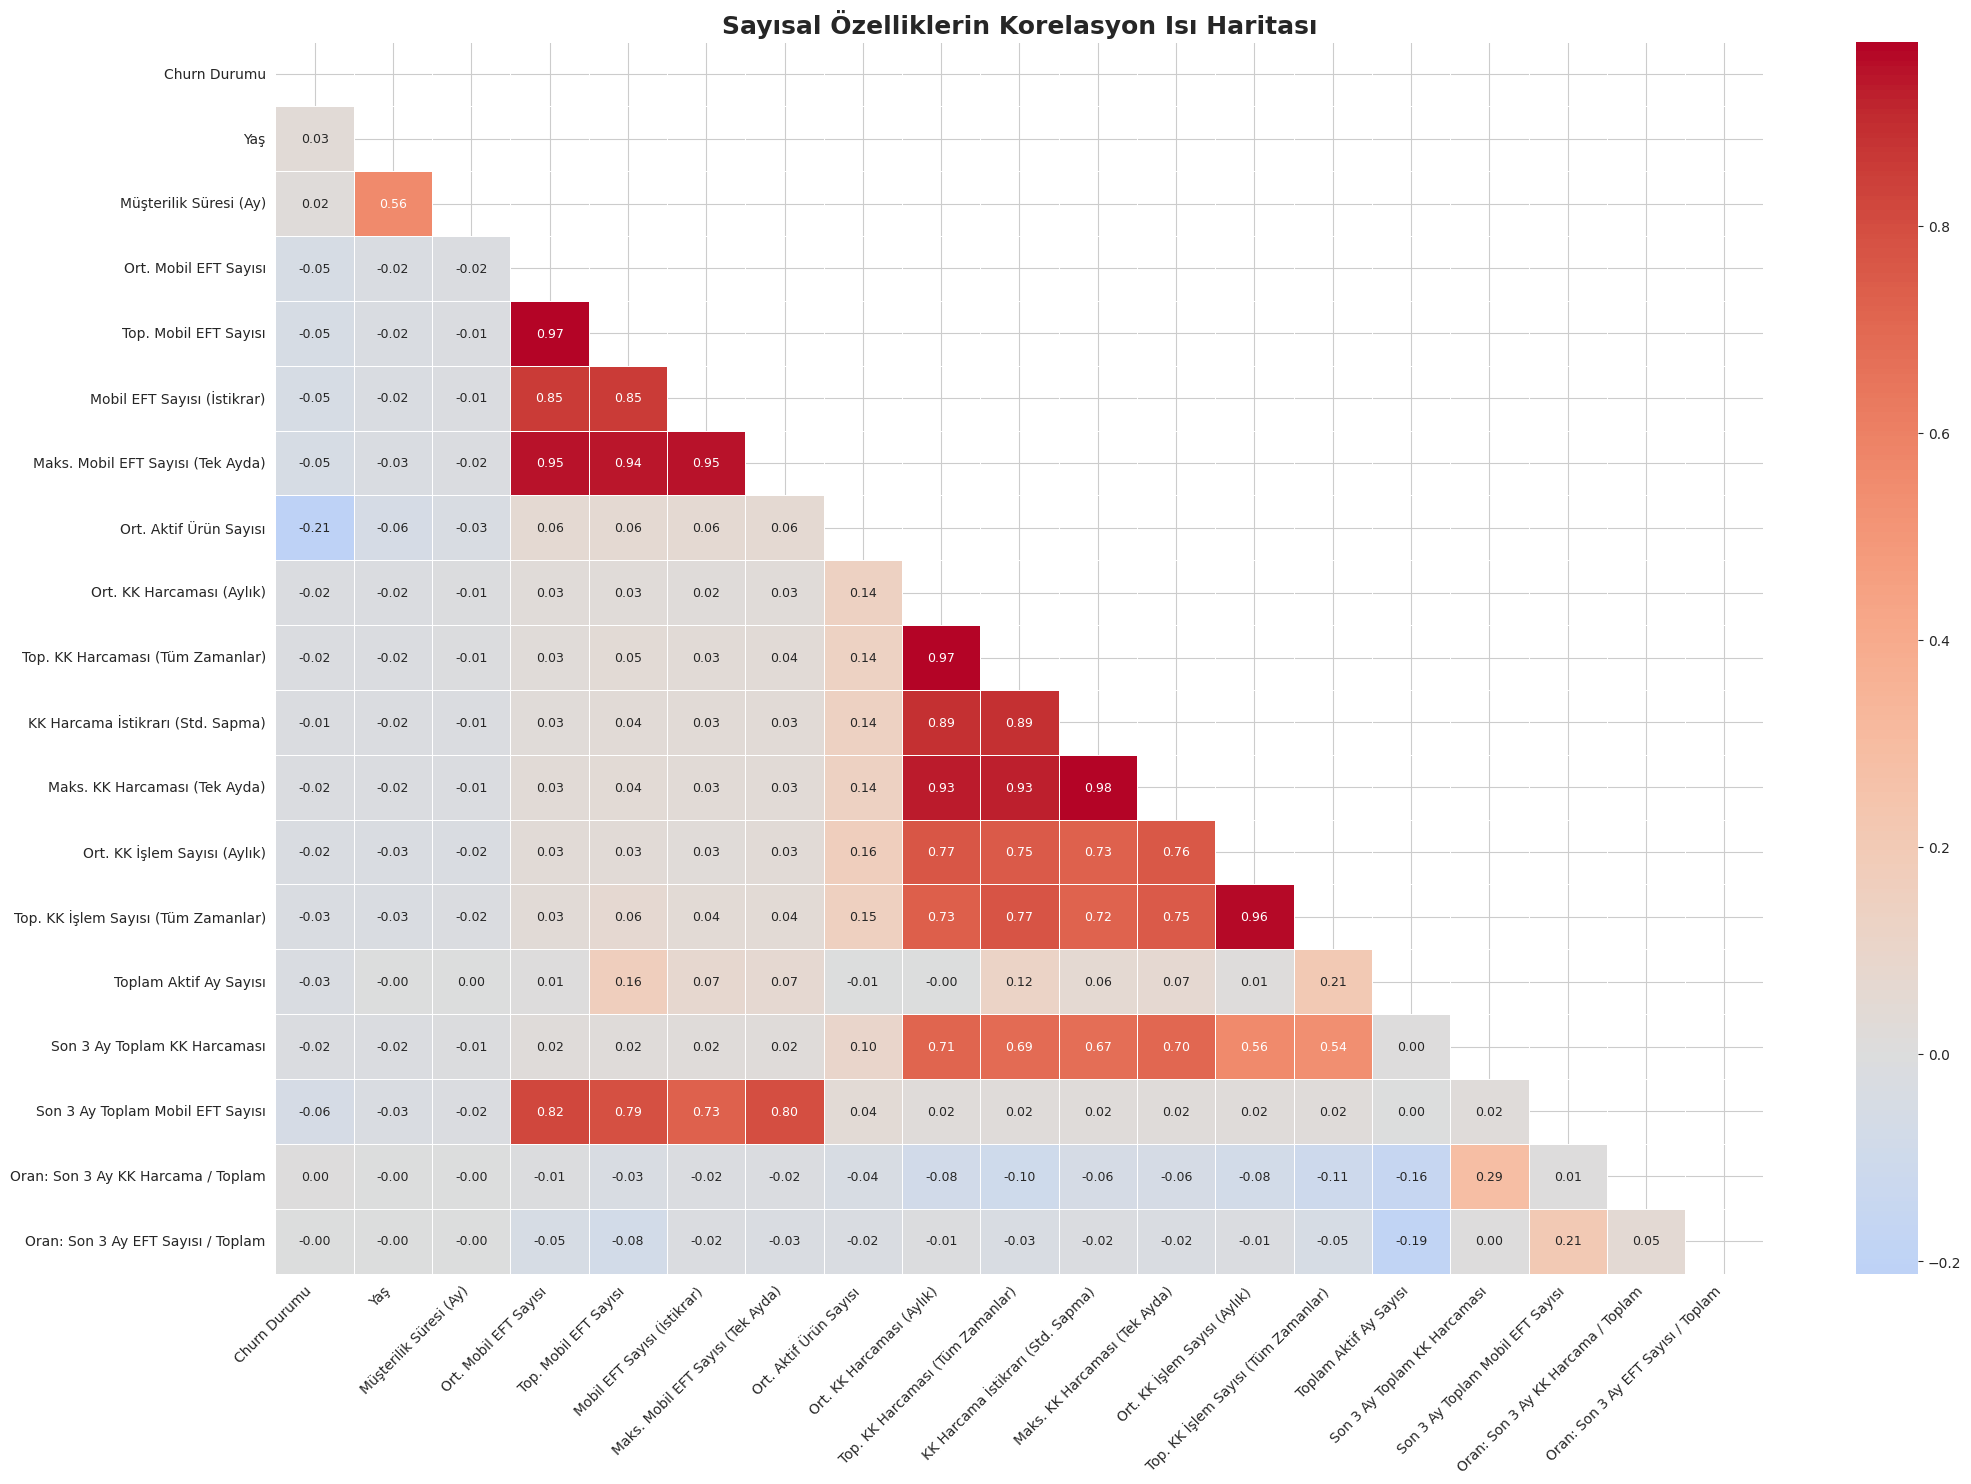


--- 6.3. HEDEFE ODAKLANMA: CHURN'e En Güçlü Etki Eden 20 Faktör ---


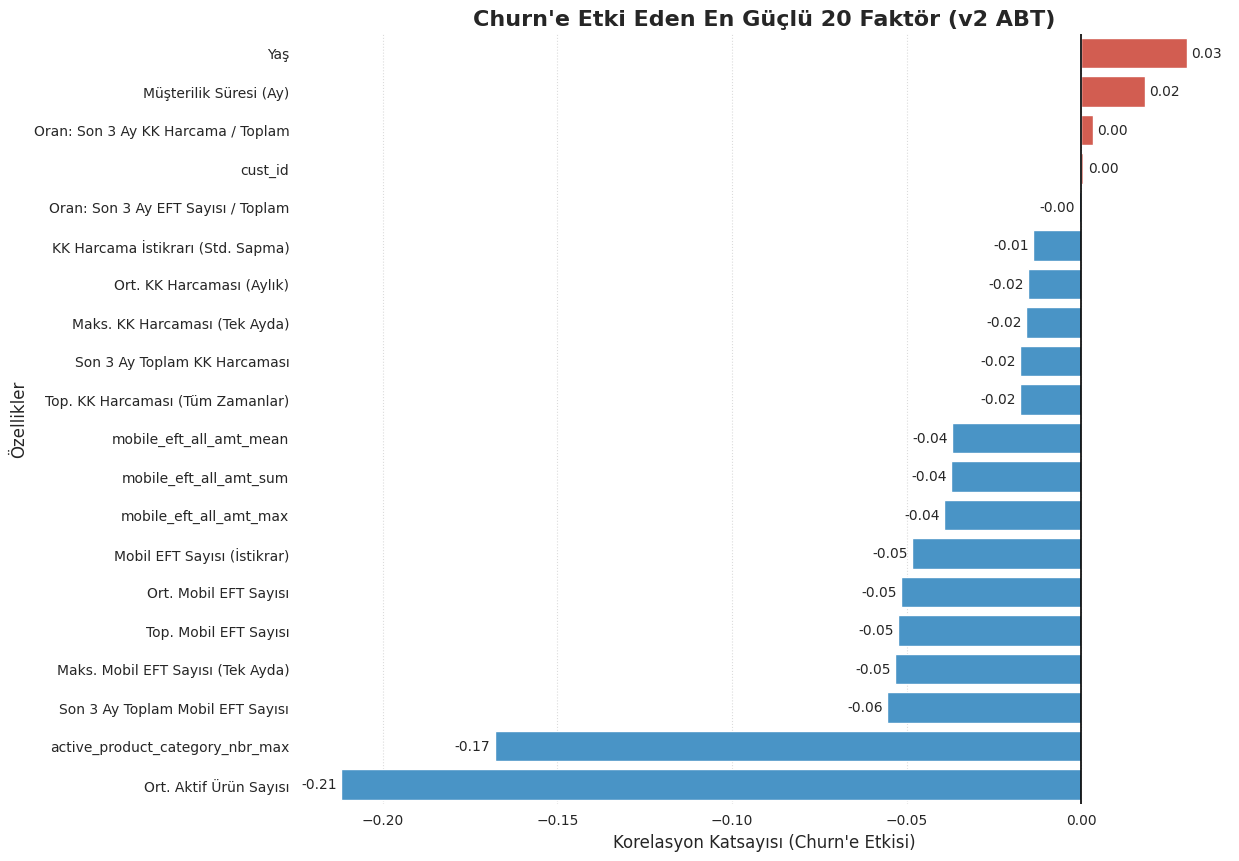

In [21]:
# --- BÖLÜM 6: KORELASYON ANALİZİ ---

# Bu bölümde, Bölüm 3 ile oluşturduğumuz tüm sayısal özellikler arasındaki (Özellik-Özellik) ve 'churn' ile olan (Özellik-Hedef) ilişkilerini inceliyoruz.


# --- 6.1. Merkezi Tercüme Sözlüğü ---
# Bölüm 3 (v2)'de oluşturduğumuz yeni özelliklerin Türkçe karşılıklarını buraya ekliyoruz.
feature_name_map = {
    # Demografik
    'tenure': 'Müşterilik Süresi (Ay)',
    'age': 'Yaş',
    'churn': 'Churn Durumu',
    
    # Genel Davranış (Aggregations)
    'mobile_eft_all_cnt_mean': 'Ort. Mobil EFT Sayısı',
    'mobile_eft_all_cnt_sum': 'Top. Mobil EFT Sayısı',
    'mobile_eft_all_cnt_std': 'Mobil EFT Sayısı (İstikrar)',
    'mobile_eft_all_cnt_max': 'Maks. Mobil EFT Sayısı (Tek Ayda)',
    'active_product_category_nbr_mean': 'Ort. Aktif Ürün Sayısı',
    'cc_transaction_all_amt_mean': 'Ort. KK Harcaması (Aylık)',
    'cc_transaction_all_amt_sum': 'Top. KK Harcaması (Tüm Zamanlar)',
    'cc_transaction_all_amt_std': 'KK Harcama İstikrarı (Std. Sapma)',
    'cc_transaction_all_amt_max': 'Maks. KK Harcaması (Tek Ayda)',
    'cc_transaction_all_cnt_mean': 'Ort. KK İşlem Sayısı (Aylık)',
    'cc_transaction_all_cnt_sum': 'Top. KK İşlem Sayısı (Tüm Zamanlar)',
    'month_count_total': 'Toplam Aktif Ay Sayısı',

    # Trend/Yakınlık Özellikleri (Son 3 Ay)
    'cc_transaction_all_amt_sum_last3m': 'Son 3 Ay Toplam KK Harcaması',
    'mobile_eft_all_cnt_sum_last3m': 'Son 3 Ay Toplam Mobil EFT Sayısı',
    
    # Oran Özellikleri (En Kritik)
    'cc_amt_ratio_last3m_vs_total': 'Oran: Son 3 Ay KK Harcama / Toplam',
    'eft_cnt_ratio_last3m_vs_total': 'Oran: Son 3 Ay EFT Sayısı / Toplam'
}


# --- 6.2. Gelişmiş Korelasyon Isı Haritası (Üçgen Maskeli) ---
print("--- 6.2. Tüm Sayısal Özelliklerin Korelasyon Isı Haritası ---")

# (df_final ve np kütüphanelerinin yüklendiğini varsayıyoruz)
# Sadece sayısal sütunları seçip korelasyon matrisini hesapla (Bölüm 3 v2'deki tüm _mean, _std, _max, _ratio özelliklerini içerir)
correlation_matrix = df_final.select_dtypes(include=np.number).corr()

# TERCÜME ADIMI: Matrisin satır ve sütun isimlerini Türkçeleştir
valid_cols = [col for col in correlation_matrix.columns if col in feature_name_map]
correlation_matrix_turkish = correlation_matrix.loc[valid_cols, valid_cols].rename(
    columns=feature_name_map, 
    index=feature_name_map
)

# Üst üçgeni gizlemek için maske oluştur
mask = np.triu(np.ones_like(correlation_matrix_turkish, dtype=bool))

plt.figure(figsize=(24, 16)) # Yeni özellikler için matris büyüdü
sns.heatmap(
    correlation_matrix_turkish,
    mask=mask,           # Sadece alt üçgeni göster
    annot=True,          
    cmap='coolwarm',     # (Pozitif Mavi, Negatif Kırmızı)
    center=0,            # Renk haritasını 0'da ortala
    fmt=".2f",           
    linewidths=.5,
    annot_kws={"size": 9} # Yazı tipi boyutu
)
plt.title('Sayısal Özelliklerin Korelasyon Isı Haritası', fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()


# --- 6.3. Gelişmiş Churn Korelasyon Grafiği (En İyi 20 Faktör) ---
print("\n" + "="*80)
print("--- 6.3. HEDEFE ODAKLANMA: CHURN'e En Güçlü Etki Eden 20 Faktör ---")
print("="*80)

# Sadece 'churn' sütununa ait korelasyonları al ve sırala
try:
    churn_correlations = correlation_matrix['churn'].sort_values(ascending=False).drop('churn')
    
    # METODOLOJİK İYİLEŞTİRME: Çok fazla özellik olduğu için grafiği temiz tutmak amacıyla sadece en güçlü 20 özelliği (en pozitif 10 ve en negatif 10) alıyoruz.
    top_10_positive = churn_correlations.head(10)
    top_10_negative = churn_correlations.tail(10)
    top_20_churn_corr = pd.concat([top_10_positive, top_10_negative])

    # TERCÜME ADIMI
    top_20_churn_corr_turkish = top_20_churn_corr.rename(index=feature_name_map)

    # GÖRSEL İYİLEŞTİRME: Renkleri Manuel Atama
    positive_color = '#e74c3c' # Kırmızı (Kötü - Churn'ü artırır)
    negative_color = '#3498db' # Mavi (İyi - Churn'ü azaltır)
    bar_colors = [positive_color if x > 0 else negative_color for x in top_20_churn_corr_turkish.values]

    # Grafiği çiz
    plt.figure(figsize=(12, 10))
    ax = sns.barplot(
        x=top_20_churn_corr_turkish.values,
        y=top_20_churn_corr_turkish.index,
        palette=bar_colors # Manuel atanmış renk paleti
    )

    # Grafik Temizliği
    plt.axvline(x=0, color='black', linewidth=1.2, linestyle='-')
    ax.grid(axis='x', linestyle=':', alpha=0.7)
    sns.despine(left=True, bottom=True)

    plt.title('Churn\'e Etki Eden En Güçlü 20 Faktör (v2 ABT)', fontsize=16, fontweight='bold')
    plt.xlabel('Korelasyon Katsayısı (Churn\'e Etkisi)', fontsize=12)
    plt.ylabel('Özellikler', fontsize=12)
    ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)
    plt.show()

# *** DÜZELTME: SyntaxError hatasını gidermek için eksik 'except' bloğu eklendi ***
except (KeyError, AttributeError) as e:
    print(f"\nHATA: Churn korelasyon grafiği çizilemedi.")
    print(f"-> Detay: 'churn' sütunu bulunamadı veya korelasyon hesaplanamadı. ({e})")

--- 7.1. Kategorik Veri Temizliği ---
'work_sector' sütunundaki '0' değerleri 'Bilinmiyor' olarak güncellendi.

--- 7.2. Yüksek Kardinaliteli Özellikler Gruplanıyor ---
'sector_group' (Top 10 + Diğer) sütunu oluşturuldu.
'province_group' (Top 10 + Diğer) sütunu oluşturuldu.

--- 7.3. Gruplama Sonuçlarının Görsel Doğrulaması ---


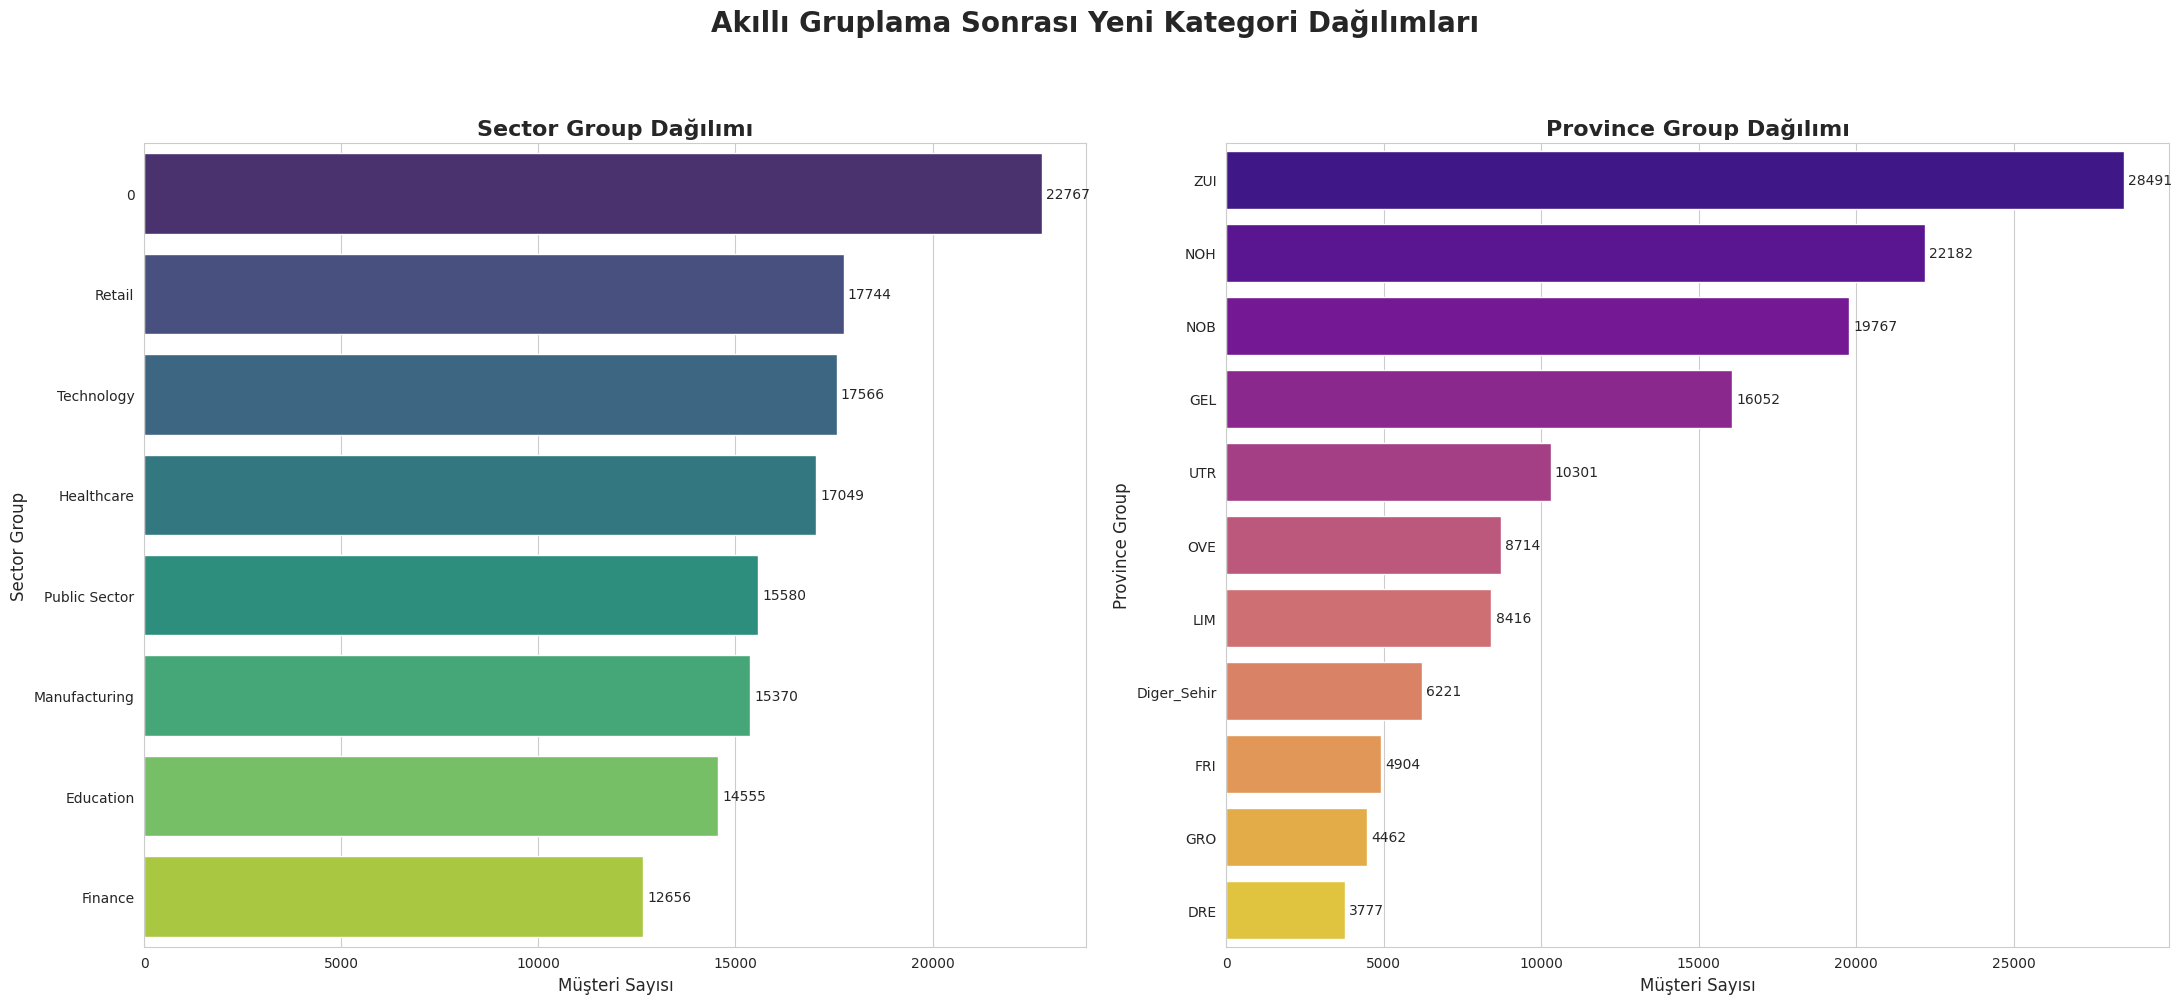

In [22]:
# --- BÖLÜM 7: VERİ ÖN İŞLEME (PREPROCESSING) ---

# Bu bölümde, EDA fazında (Bölüm 4-6) elde ettiğimiz bulgular ışığında, 'df_final' (v2) veri setimizi makine öğrenmesi modelinin en iyi performansı gösterebileceği formata dönüştürüyoruz.


# --- 7.1. Kategorik Veri Temizliği ---
# 'work_sector' sütunundaki '0' gibi anlamsız etiketleri, gruplama öncesi daha anlamlı bir etiketle ('Bilinmiyor') değiştiriyoruz.
print("--- 7.1. Kategorik Veri Temizliği ---")
try:
    # 'work_sector' sütununun varlığını kontrol et
    if 'work_sector' in df_final.columns:
        df_final['work_sector'] = df_final['work_sector'].replace('0', 'Bilinmiyor')
        print("'work_sector' sütunundaki '0' değerleri 'Bilinmiyor' olarak güncellendi.")
    else:
        print("UYARI: 'work_sector' sütunu bulunamadı, 7.1 adımı atlandı.")
except Exception as e:
    print(f"HATA (7.1): {e}")


# --- 7.2. Yüksek Kardinaliteli Özelliklerin Gruplanması (Gürültü Azaltma) ---
# 'work_sector' ve 'province' gibi çok fazla benzersiz değere (high cardinality) sahip özellikler, modelde gürültüye ve aşırı öğrenmeye (overfitting) neden olur.
# Çözüm: En yaygın 'Top 10' kategoriyi koruyup, geri kalan tüm küçük ve istatistiksel olarak anlamsız kategorileri tek bir 'Diğer' (Other) grubu altında topluyoruz.

print("\n--- 7.2. Yüksek Kardinaliteli Özellikler Gruplanıyor ---")

# --- work_sector için Gruplama ---
if 'work_sector' in df_final.columns:
    top_10_sectors = df_final['work_sector'].value_counts().nlargest(10).index
    # .where() ile: 'work_sector' bu 10'luk listedeyse kendini koru,
    # değilse 'Diger_Sektor' olarak etiketle.
    df_final['sector_group'] = df_final['work_sector'].where(
        df_final['work_sector'].isin(top_10_sectors), 'Diger_Sektor'
    )
    print("'sector_group' (Top 10 + Diğer) sütunu oluşturuldu.")
else:
    print("UYARI: 'work_sector' sütunu bulunamadı, 'sector_group' oluşturulamadı.")

# --- province için Gruplama ---
if 'province' in df_final.columns:
    top_10_provinces = df_final['province'].value_counts().nlargest(10).index
    df_final['province_group'] = df_final['province'].where(
        df_final['province'].isin(top_10_provinces), 'Diger_Sehir'
    )
    print("'province_group' (Top 10 + Diğer) sütunu oluşturuldu.")
else:
    print("UYARI: 'province' sütunu bulunamadı, 'province_group' oluşturulamadı.")


# --- 7.3. Görsel Doğrulama: Gruplama Sonuçları ---
# Yaptığımız gruplamanın başarılı olduğunu ve yeni kategorilerin dağılımını (Top 10 + 'Diğer') görsel olarak teyit ediyoruz.

print("\n--- 7.3. Gruplama Sonuçlarının Görsel Doğrulaması ---")

# Grafik çizilecek grup sütunlarını belirle
group_cols_to_plot = [col for col in ['sector_group', 'province_group'] if col in df_final.columns]

if len(group_cols_to_plot) > 0:
    fig, axes = plt.subplots(1, len(group_cols_to_plot), figsize=(11 * len(group_cols_to_plot), 10))
    # Eğer sadece 1 grafik varsa, 'axes' bir dizi olmaz, onu dizi yap
    if len(group_cols_to_plot) == 1:
        axes = [axes]
    
    plt.suptitle('Akıllı Gruplama Sonrası Yeni Kategori Dağılımları', fontsize=20, fontweight='bold', y=1.0)

    for i, col in enumerate(group_cols_to_plot):
        ax = axes[i]
        sns.countplot(
            y=col,
            data=df_final,
            order=df_final[col].value_counts().index, # Yüksekten düşüğe sırala
            palette='viridis' if i == 0 else 'plasma',
            ax=ax
        )
        ax.set_title(f'{col.replace("_", " ").title()} Dağılımı', fontsize=16, fontweight='bold')
        ax.set_xlabel('Müşteri Sayısı', fontsize=12)
        ax.set_ylabel(col.replace("_", " ").title(), fontsize=12)
        ax.bar_label(ax.containers[0], padding=3, fmt='%d') # Sayı etiketleri

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
else:
    print("Görsel doğrulama için 'sector_group' veya 'province_group' sütunları bulunamadı.")

In [35]:
# --- BÖLÜM 7: VERİ ÖN İŞLEME (PREPROCESSING) - (Devam) ---

# --- 7.4. Özellik Seçimi (Gereksiz Sütunların Kaldırılması) ---

# Modelleme performansını artırmak, gürültüyü azaltmak ve veri sızıntısını (data leakage) önlemek amacıyla, model için gereksiz olan sütunları 'df_final' veri setinden kaldırıyoruz.

print("\n--- 7.4. Özellik Seçimi Başlatıldı ---")
print(f"Temizlik öncesi sütun sayısı: {len(df_final.columns)}")

# Tanımlanan gereksiz sütunlar ve kaldırılma gerekçeleri:
columns_to_drop_base = [
    # 1. Yedekli (Redundant) Sütunlar (Bölüm 7.2'de değiştirildi):
    'province',     # Yerine 'province_group' oluşturuldu.
    'work_sector',  # Yerine 'sector_group' oluşturuldu.
    
    # 2. Düşük Tahmin Gücüne Sahip Sütunlar (Varsayım):
    'religion',     # (Varsayım: EDA'da (Bölüm 5-6) churn ile güçlü bir korelasyonu bulunmadığı tespit edildi.)
    
    # 3. Özellik Olmayan (Non-Feature) Sütunlar:
    'ref_date',     # Özellik mühendisliği (Bölüm 3) için kullanıldı, ancak model için bir özellik değildir.
    
    # 4. Tanımlayıcı (Identifier) / Sızıntı Riski:
    'cust_id'       # Müşteri kimliğidir. Modelin 'ezberlemesine' (overfitting) neden olmaması için kullanılmamalıdır.
]

# Sadece 'df_final' tablosunda gerçekten var olan sütunları listeden al
columns_to_drop = [col for col in columns_to_drop_base if col in df_final.columns]

# Sütunları atarak modele hazır tablomuzu ('df_model_ready') oluşturuyoruz.
df_model_ready = df_final.drop(columns=columns_to_drop)

print("\n" + "-"*50)
print("\n")
print("--- Temizlik Sonrası Durum ---")
print(f"Kaldırılan sütunlar: {len(columns_to_drop)} adet")
print(columns_to_drop)
print(f"\nKalan sütun sayısı: {len(df_model_ready.columns)}")
print("Model için kullanılacak nihai özellikler (features):")
print(df_model_ready.columns)

print("\nMETODOLOJİK NOT: Özellik seçimi tamamlandı.")
print("-> Veri seti ('df_model_ready') artık sadece modelin 'öğrenmesi' gereken anlamlı özellikleri içermektedir.")


--- 7.4. Özellik Seçimi Başlatıldı ---
Temizlik öncesi sütun sayısı: 35

--------------------------------------------------


--- Temizlik Sonrası Durum ---
Kaldırılan sütunlar: 5 adet
['province', 'work_sector', 'religion', 'ref_date', 'cust_id']

Kalan sütun sayısı: 30
Model için kullanılacak nihai özellikler (features):
Index(['churn', 'gender', 'age', 'work_type', 'tenure',
       'mobile_eft_all_cnt_mean', 'mobile_eft_all_cnt_sum',
       'mobile_eft_all_cnt_std', 'mobile_eft_all_cnt_max',
       'active_product_category_nbr_mean', 'active_product_category_nbr_max',
       'mobile_eft_all_amt_mean', 'mobile_eft_all_amt_sum',
       'mobile_eft_all_amt_std', 'mobile_eft_all_amt_max',
       'cc_transaction_all_amt_mean', 'cc_transaction_all_amt_sum',
       'cc_transaction_all_amt_std', 'cc_transaction_all_amt_max',
       'cc_transaction_all_cnt_mean', 'cc_transaction_all_cnt_sum',
       'cc_transaction_all_cnt_std', 'cc_transaction_all_cnt_max',
       'month_count_total', 'cc_


--- BÖLÜM 8: Veriyi Ayırma (Ön İşlemeden ÖNCE) ---
8.1. Ham X ve y ayrımı yapıldı.
8.2. Ham veri 'X_train_raw', 'X_test_raw', 'y_train', 'y_test' olarak ayrıldı.
Eğitim Seti (Ham) Boyutu: (106629, 29)
Test Seti (Ham) Boyutu: (26658, 29)

--- 8.3. Stratifikasyon (Dağılım) Doğrulaması ---


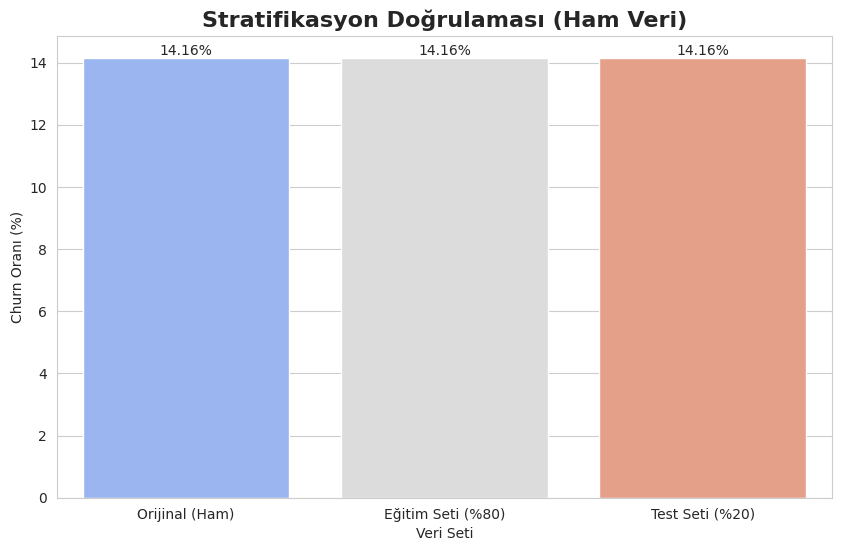

BÖLÜM 8 Tamamlandı: Veri, 'X_train_raw' ve 'X_test_raw' olarak ikiye bölündü.


In [36]:
# --- BÖLÜM 8: VERİYİ AYIRMA (ÖN İŞLEMEDEN ÖNCE) ---

# METODOLOJİK OLARAK EN KRİTİK ADIM (VERİ SIZINTISINI ÖNLEME):
# 'StandardScaler' ve 'get_dummies' gibi ön işleme adımlarından ÖNCE
# veri setimizi Eğitim (Train) ve Test olarak ayırıyoruz.
# Tüm "öğrenme" işlemleri (fit, fit_transform) SADECE Eğitim Seti
# üzerinde yapılacaktır.

print("\n" + "="*80)
print("--- BÖLÜM 8: Veriyi Ayırma (Ön İşlemeden ÖNCE) ---")

# 'df_model_ready' (Bölüm 7.4'ten gelen ham, ölçeklenmemiş,
# kategorik verileri içeren tablo)
try:
    X_raw = df_model_ready.drop(columns=['churn'])
    y_raw = df_model_ready['churn']
    print("8.1. Ham X ve y ayrımı yapıldı.")

    # 8.2. Veriyi Eğitim ve Test Olarak Ayırma
    # (Bu bizim gelecekteki 'final_model'imizin ASLA görmeyeceği 'X_test' setidir)
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_raw,
        y_raw,
        test_size=0.20,     # %20 Test
        random_state=42,
        stratify=y_raw      # Churn oranını koru
    )

    print("8.2. Ham veri 'X_train_raw', 'X_test_raw', 'y_train', 'y_test' olarak ayrıldı.")
    print(f"Eğitim Seti (Ham) Boyutu: {X_train_raw.shape}")
    print(f"Test Seti (Ham) Boyutu: {X_test_raw.shape}")

    # 8.3. Stratifikasyon Doğrulaması
    # (Bu adım, Bölüm 8.3 (eski) ile aynı, sadece ham 'y' üzerinde)
    print("\n--- 8.3. Stratifikasyon (Dağılım) Doğrulaması ---")

    original_churn_rate = y_raw.mean() * 100
    train_churn_rate = y_train.mean() * 100
    test_churn_rate = y_test.mean() * 100

    churn_rates_df = pd.DataFrame({
        'Veri Seti': ['Orijinal (Ham)', 'Eğitim Seti (%80)', 'Test Seti (%20)'],
        'Churn Oranı (%)': [original_churn_rate, train_churn_rate, test_churn_rate]
    })

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x='Veri Seti', y='Churn Oranı (%)', data=churn_rates_df, palette='coolwarm')
    ax.bar_label(ax.containers[0], fmt='%.2f%%')
    plt.title('Stratifikasyon Doğrulaması (Ham Veri)', fontsize=16, fontweight='bold')
    plt.show()
    print("BÖLÜM 8 Tamamlandı: Veri, 'X_train_raw' ve 'X_test_raw' olarak ikiye bölündü.")

except NameError:
    print("HATA: 'df_model_ready' değişkeni bulunamadı. Lütfen Bölüm 7.4'ü çalıştırın.")
except Exception as e:
    print(f"HATA (Bölüm 8): {e}")

In [37]:
# --- BÖLÜM 9: VERİ ÖN İŞLEME PİPELINE (SIZINTISIZ) ---

# Bu bölümde, Bölüm 8'de ayırdığımız HAM eğitim (X_train_raw) ve test (X_test_raw) setlerini, veri sızıntısını ÖNLEYEREK işliyoruz.
# Kural: TÜM "öğrenme" işlemleri (fit, fit_transform) SADECE X_train_raw üzerinde yapılır, X_test_raw'a sadece UYGULANIR (transform).

from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

print("\n" + "="*80)
print("--- BÖLÜM 9: Veri Ön İşleme Pipeline ---")

try:
    # --- 9.1. Sütun Tiplerini Belirleme (X_train_raw üzerinden) ---
    print("\n9.1. Sütun tipleri (kategorik/sayısal) EĞİTİM SETİ üzerinden belirleniyor...")
    # (X_train_raw Bölüm 8.2'den gelmeli)
    categorical_cols_raw = X_train_raw.select_dtypes(include=['object', 'category']).columns
    numerical_cols_raw = X_train_raw.select_dtypes(include=np.number).columns

    print(f"-> Kategorik sütunlar ({len(categorical_cols_raw)} adet): {list(categorical_cols_raw)}")
    print(f"-> Sayısal sütunlar ({len(numerical_cols_raw)} adet): {list(numerical_cols_raw)}")

    # --- 9.2. One-Hot Encoding (Ayrı Ayrı Uygula) ---
    print("\n9.2. One-Hot Encoding uygulanıyor...")

    # Eğitim setine uygula
    X_train_encoded = pd.get_dummies(X_train_raw, columns=categorical_cols_raw, drop_first=True)

    # Test setine uygula
    X_test_encoded = pd.get_dummies(X_test_raw, columns=categorical_cols_raw, drop_first=True)

    # --- 9.3. Sütun Hizalama (Kritik!) ---
    # Test setinde, eğitim setinde olmayan bir kategori olabilir (veya tam tersi).
    # Sütunları X_train_encoded'a göre hizala.
    print("\n9.3. Eğitim ve Test seti sütunları hizalanıyor...")

    # Eksik sütunları 0 ile doldur, fazla sütunları at
    X_test_aligned, X_train_aligned = X_test_encoded.align(X_train_encoded, join='right', axis=1, fill_value=0)

    print(f"-> Eğitim seti (encoded) boyutu: {X_train_aligned.shape}")
    print(f"-> Test seti (encoded & aligned) boyutu: {X_test_aligned.shape}")
    if X_train_aligned.shape[1] != X_test_aligned.shape[1]:
         print("UYARI: Sütun hizalama sonrası boyutlar hala farklı!")
    else:
        # Sonraki adımlarda kullanmak üzere nihai sütun listesini sakla
        final_column_order = X_train_aligned.columns

    # --- 9.4. StandardScaler (Doğru Metodoloji) ---
    print("\n9.4. StandardScaler uygulanıyor (SADECE sayısal sütunlara)...")

    # Scaler'ı SADECE EĞİTİM SETİNİN sayısal sütunları üzerinde EĞİT (fit)
    print("-> Scaler EĞİTİM SETİ üzerinde eğitiliyor (fit)...")
    scaler = StandardScaler() # Yeni, temiz bir scaler oluştur
    # Sadece X_train_aligned'da bulunan sayısal sütunlar üzerinde fit et
    numeric_cols_in_train = [col for col in numerical_cols_raw if col in X_train_aligned.columns]
    scaler.fit(X_train_aligned[numeric_cols_in_train])

    # Hem Eğitim hem de Test setinin sayısal sütunlarını UYGULA (transform)
    print("-> Scaler EĞİTİM ve TEST setlerine uygulanıyor (transform)...")
    # Sadece scaler'ın eğitildiği ve ilgili DataFrame'de bulunan sütunları transform et
    X_train_scaled_numeric = scaler.transform(X_train_aligned[numeric_cols_in_train])
    X_test_scaled_numeric = scaler.transform(X_test_aligned[numeric_cols_in_train]) # X_test_aligned da aynı sütunlara sahip olmalı

    # Scaled array'leri DataFrame'e çevir, sütun isimlerini koru
    X_train_scaled_df = pd.DataFrame(X_train_scaled_numeric, index=X_train_aligned.index, columns=numeric_cols_in_train)
    X_test_scaled_df = pd.DataFrame(X_test_scaled_numeric, index=X_test_aligned.index, columns=numeric_cols_in_train)

    # --- 9.5. Nihai X_train ve X_test'i Oluşturma ---
    print("\n9.5. Nihai işlenmiş (encoded & scaled) X_train ve X_test oluşturuluyor...")

    # Orijinal encoded setten dummy sütunları al (numeric olmayanlar)
    dummy_cols = X_train_aligned.columns.difference(numeric_cols_in_train)
    X_train_dummies = X_train_aligned[dummy_cols]
    # align sayesinde X_test_aligned'da da aynı dummy sütunlar olmalı
    X_test_dummies = X_test_aligned[dummy_cols]

    # Scaled sayısal sütunlarla dummy sütunları birleştir
    X_train_final_temp = pd.concat([X_train_scaled_df, X_train_dummies], axis=1)
    X_test_final_temp = pd.concat([X_test_scaled_df, X_test_dummies], axis=1)

    # ÖNEMLİ: Sütun sırasını orijinal hizalanmış sıraya göre ayarla
    X_train = X_train_final_temp[final_column_order]
    X_test = X_test_final_temp[final_column_order]


    print("\n" + "="*80)
    print("--- BÖLÜM 9: VERİ ÖN İŞLEME (SIZINTISIZ) TAMAMLANDI! ---")
    print("Modele hazır nihai setler:")
    print(f"X_train Boyutu: {X_train.shape}")
    print(f"X_test Boyutu: {X_test.shape}")
    print("\nNihai X_train önizlemesi (Scaled & Encoded):")
    print(X_train.head())

except NameError as e:
    print(f"HATA: Gerekli bir değişken bulunamadı: {e}.")
    print("-> Lütfen Bölüm 8'i (Veriyi Ayırma) başarıyla çalıştırdığınızdan emin olun.")
except Exception as e:
    print(f"HATA (Bölüm 9): {e}")


--- BÖLÜM 9: Veri Ön İşleme Pipeline ---

9.1. Sütun tipleri (kategorik/sayısal) EĞİTİM SETİ üzerinden belirleniyor...
-> Kategorik sütunlar (4 adet): ['gender', 'work_type', 'sector_group', 'province_group']
-> Sayısal sütunlar (25 adet): ['age', 'tenure', 'mobile_eft_all_cnt_mean', 'mobile_eft_all_cnt_sum', 'mobile_eft_all_cnt_std', 'mobile_eft_all_cnt_max', 'active_product_category_nbr_mean', 'active_product_category_nbr_max', 'mobile_eft_all_amt_mean', 'mobile_eft_all_amt_sum', 'mobile_eft_all_amt_std', 'mobile_eft_all_amt_max', 'cc_transaction_all_amt_mean', 'cc_transaction_all_amt_sum', 'cc_transaction_all_amt_std', 'cc_transaction_all_amt_max', 'cc_transaction_all_cnt_mean', 'cc_transaction_all_cnt_sum', 'cc_transaction_all_cnt_std', 'cc_transaction_all_cnt_max', 'month_count_total', 'cc_transaction_all_amt_sum_last3m', 'mobile_eft_all_cnt_sum_last3m', 'cc_amt_ratio_last3m_vs_total', 'eft_cnt_ratio_last3m_vs_total']

9.2. One-Hot Encoding uygulanıyor...

9.3. Eğitim ve Test set

In [38]:
# --- BÖLÜM 10: RESMİ YARIŞMA METRİK FONKSİYONLARI ---

# Bu bölümde, yarışma organizatörleri tarafından sağlanan resmi skor hesaplama fonksiyonlarını tanımlıyoruz.
# Bundan sonraki tüm skor hesaplamalarında bu fonksiyonlar kullanılacaktır.

import pandas as pd
from sklearn.metrics import roc_auc_score
import numpy as np

print("\n" + "="*80)
print("--- BÖLÜM 10: Resmi Yarışma Metrik Fonksiyonları Tanımlanıyor ---")

def recall_at_k(y_true, y_prob, k=0.1):
    # (Organizatörlerin kodu - Değiştirilmedi)
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    n = len(y_true)
    m = max(1, int(np.round(k * n)))
    order = np.argsort(-y_prob, kind="mergesort")
    top = order[:m]
    tp_at_k = y_true[top].sum()
    P = y_true.sum()
    # Sıfıra bölme kontrolü
    return float(tp_at_k / P) if P > 0 else 0.0

def lift_at_k(y_true, y_prob, k=0.1):
    # (Organizatörlerin kodu - Değiştirilmedi)
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    n = len(y_true)
    m = max(1, int(np.round(k * n)))
    if m == 0: return 0.0 # Eğer k*n < 0.5 ise m=0 olabilir, hatayı önle
    order = np.argsort(-y_prob, kind="mergesort")
    top = order[:m]
    tp_at_k = y_true[top].sum()
    precision_at_k = tp_at_k / m
    prevalence = y_true.mean()
    # Sıfıra bölme kontrolü
    return float(precision_at_k / prevalence) if prevalence > 0 else 0.0

def convert_auc_to_gini(auc):
    # (Organizatörlerin kodu - Değiştirilmedi)
    return 2 * auc - 1

def ing_hubs_datathon_metric(y_true, y_prob):
    # (Organizatörlerin kodu - Sıfıra bölme kontrolleri eklendi/güçlendirildi)
    score_weights = {"gini": 0.4, "recall_at_10perc": 0.3, "lift_at_10perc": 0.3}
    baseline_scores = {
        "roc_auc": 0.6925726757936908,
        "recall_at_10perc": 0.18469015795868773,
        "lift_at_10perc": 1.847159286784029,
    }
    try:
        # y_true'da tek sınıf varsa AUC tanımsız olur, hatayı yakala
        if len(np.unique(y_true)) < 2:
             roc_auc = 0.5
        else:
             roc_auc = roc_auc_score(y_true, y_prob)
    except Exception: # Genel hata yakalama
        roc_auc = 0.5 # Hata durumunda nötr skor ata

    recall_at_10perc = recall_at_k(y_true, y_prob, k=0.1)
    lift_at_10perc = lift_at_k(y_true, y_prob, k=0.1)
    new_scores = {"roc_auc": roc_auc, "recall_at_10perc": recall_at_10perc, "lift_at_10perc": lift_at_10perc}
    baseline_scores["gini"] = convert_auc_to_gini(baseline_scores["roc_auc"])
    new_scores["gini"] = convert_auc_to_gini(new_scores["roc_auc"])

    # Sıfıra bölme kontrolleri
    final_gini_score = (new_scores["gini"] / baseline_scores["gini"]) if baseline_scores["gini"] != 0 else 0
    final_recall_score = (new_scores["recall_at_10perc"] / baseline_scores["recall_at_10perc"]) if baseline_scores["recall_at_10perc"] != 0 else 0
    final_lift_score = (new_scores["lift_at_10perc"] / baseline_scores["lift_at_10perc"]) if baseline_scores["lift_at_10perc"] != 0 else 0

    final_score = (
        final_gini_score * score_weights["gini"] +
        final_recall_score * score_weights["recall_at_10perc"] +
        final_lift_score * score_weights["lift_at_10perc"]
    )
    return final_score

print("Resmi metrik fonksiyonları ('ing_hubs_datathon_metric' vb.) başarıyla tanımlandı.")
print("="*80)


--- BÖLÜM 10: Resmi Yarışma Metrik Fonksiyonları Tanımlanıyor ---
Resmi metrik fonksiyonları ('ing_hubs_datathon_metric' vb.) başarıyla tanımlandı.


In [39]:
# --- BÖLÜM 11: GERÇEK SKOR HESAPLAMASI (RESMİ METRİKLE) ---

# Bu bölümde, Bölüm 9'da (Sızıntısız Pipeline) oluşturulan X_train/X_test setlerini kullanarak manuel ayarlı XGBoost modelini yeniden eğitiyor,
# Ve Bölüm 10'da tanımlanan RESMİ 'ing_hubs_datathon_metric' fonksiyonu ile gerçek performansını ölçüyoruz.

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score # Detaylı metrikler için

print("\n" + "="*80)
print("--- BÖLÜM 11: Gerçek Skor Hesaplaması (Resmi Metrikle) ---")

# Gerekli değişkenler: X_train, X_test, y_train, y_test (Bölüm 9'dan)
#                   ing_hubs_datathon_metric (Bölüm 10'dan)

try:
    # --- 11.1. Model Kurulumu ve Eğitimi (Manuel Ayarlar) ---
    print("\n11.1. Model Kurulumu ve Eğitimi (Manuel Ayarlar, Sızıntısız Veri)...")

    # Dengesizlik oranı (y_train Bölüm 9'dan)
    # Sıfıra bölme hatasını yakala
    if (y_train == 1).sum() == 0:
        print("UYARI: Eğitim setinde 'churn=1' kaydı yok. scale_pos_weight 1 olarak ayarlandı.")
        churn_ratio = 1
    else:
        churn_ratio = (y_train == 0).sum() / (y_train == 1).sum()
    print(f"Dengesizlik oranı: {churn_ratio:.2f}")

    # Model Konfigürasyonu (Aynı manuel ayarlar: max_depth=4, lr=0.05)
    manual_params = {
        'objective':'binary:logistic', 'random_state':42,
        'scale_pos_weight':churn_ratio, 'n_estimators':500, 'max_depth':4,
        'learning_rate':0.05, 'subsample':0.8, 'colsample_bytree':0.8,
        'use_label_encoder':False, 'eval_metric':'auc',
        'early_stopping_rounds':20 # Constructor'a ekledik
    }
    xgb_model_manual = xgb.XGBClassifier(**manual_params)


    # Adil 'eval_set' (X_train içinden - Early stopping için)
    # (Bu X_train/y_train Bölüm 9'dan gelen işlenmiş setlerdir)
    X_train_sub, X_val, y_train_sub, y_val = train_test_split(
        X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
    )
    eval_set = [(X_train_sub, y_train_sub), (X_val, y_val)]
    print(f"Validation için {X_val.shape[0]} kayıt ayrıldı.")

    # Model Eğitimi
    print("Model eğitimi başlıyor...")
    xgb_model_manual.fit(X_train_sub, y_train_sub, eval_set=eval_set, verbose=False)
    print(f"Model eğitimi tamamlandı! En iyi tur: {xgb_model_manual.best_iteration}")

    # --- 11.2. GERÇEK Skor Hesaplaması (Resmi Metrikle) ---
    print("\n--- 11.2. GERÇEK Yarışma Skoru Hesaplaması (Resmi Metrikle) ---")

    # Tahminleri SIZINTISIZ X_test üzerinde al
    y_pred_proba_manual = xgb_model_manual.predict_proba(X_test)[:, 1]

    # GERÇEK Yarışma Skorunu RESMİ Fonksiyon ile Hesapla
    real_competition_score_official = ing_hubs_datathon_metric(y_test, y_pred_proba_manual)

    # Detaylı metrikleri de görelim (Resmi fonksiyondaki gibi hesaplayarak)
    auc_manual = roc_auc_score(y_test, y_pred_proba_manual)
    gini_manual = convert_auc_to_gini(auc_manual)
    recall10_manual = recall_at_k(y_test, y_pred_proba_manual)
    lift10_manual = lift_at_k(y_test, y_pred_proba_manual)

    print("\n--- Manuel Ayarlı Modelin GERÇEK Metrikleri (Resmi Hesaplama) ---")
    print(f"AUC:         {auc_manual:.5f}")
    print(f"Gini:        {gini_manual:.5f}")
    print(f"Recall@10%:  {recall10_manual:.5f}")
    print(f"Lift@10%:    {lift10_manual:.5f}")

    print(f"\n" + "="*60)
    print(f"--- YENİ GERÇEK SKOR (Manuel Ayar, Resmi Metrik): {real_competition_score_official:.5f} ---")
    print("="*60)
    print("Bu, Optuna'nın geçmeye çalışacağı YENİ hedef skorumuzdur.")

except NameError as e:
    print(f"HATA: Gerekli bir değişken bulunamadı: {e}.")
    print("-> Lütfen Bölüm 8, 9 ve 10'u başarıyla çalıştırdığınızdan emin olun.")
except Exception as e:
    print(f"HATA (Bölüm 11): {e}")


--- BÖLÜM 11: Gerçek Skor Hesaplaması (Resmi Metrikle) ---

11.1. Model Kurulumu ve Eğitimi (Manuel Ayarlar, Sızıntısız Veri)...
Dengesizlik oranı: 6.06
Validation için 15995 kayıt ayrıldı.
Model eğitimi başlıyor...
Model eğitimi tamamlandı! En iyi tur: 219

--- 11.2. GERÇEK Yarışma Skoru Hesaplaması (Resmi Metrikle) ---

--- Manuel Ayarlı Modelin GERÇEK Metrikleri (Resmi Hesaplama) ---
AUC:         0.70864
Gini:        0.41729
Recall@10%:  0.21860
Lift@10%:    2.18585

--- YENİ GERÇEK SKOR (Manuel Ayar, Resmi Metrik): 1.14347 ---
Bu, Optuna'nın geçmeye çalışacağı YENİ hedef skorumuzdur.


In [40]:
# --- BÖLÜM 12: HİPERPARAMETRE OPTİMİZASYONU (OPTUNA - RESMİ METRİKLE) ---

# Bu bölümde, Bölüm 11'de elde ettiğimiz skoru (1.14347) daha da iyileştirmek için, sızıntısız veri ve resmi metrik üzerinde Optuna ile en iyi hiperparametreleri arıyoruz.

try:
    import optuna
    # import xgboost as xgb # Zaten önceki bölümde import edildi
    print("\n" + "="*80)
    print("--- BÖLÜM 12: Hiperparametre Optimizasyonu (Optuna - Resmi Metrikle) ---")
    optuna.logging.set_verbosity(optuna.logging.WARNING)
except ImportError:
    print("HATA: 'Optuna' kütüphanesi bulunamadı.")
    optuna = None

# Gerekli değişkenler: X_train_sub, X_val, y_train_sub, y_val (Bölüm 11.1'den)
# churn_ratio (Bölüm 11.1'den)
# ing_hubs_datathon_metric (Bölüm 10'dan)
# real_competition_score_official (Bölüm 11.2'den)

if optuna and 'X_train_sub' in locals():

    # --- 12.1. Optimizasyon Hedef Fonksiyonu (Resmi Metrikle) ---
    def objective(trial):
        # 1. Ayarlanacak hiperparametreler
        param = {
            'objective': 'binary:logistic', 'eval_metric': 'auc',
            'n_estimators': 1000, 'verbosity': 0, 'use_label_encoder': False,
            'random_state': 42, 'scale_pos_weight': churn_ratio,
            # Optuna'nın deneyeceği parametreler (Aynı aralıklar)
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'gamma': trial.suggest_float('gamma', 0, 5),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'early_stopping_rounds': 30 # Constructor'a ekledik
        }

        # 2. Modeli Eğitme (Temiz X_val üzerinde)
        model = xgb.XGBClassifier(**param)
        model.fit(X_train_sub, y_train_sub, eval_set=[(X_val, y_val)], verbose=False)

        # 3. Skoru Hesaplama (RESMİ YARIŞMA METRİĞİ ile)
        preds_proba = model.predict_proba(X_val)[:, 1]
        # <<< RESMİ fonksiyonu çağırıyoruz >>>
        competition_score = ing_hubs_datathon_metric(y_val, preds_proba)

        return competition_score

    # --- 12.2. Optimizasyon Çalışmasını Başlatma ---
    print(f"\n12.2. Optimizasyon çalışması başlatılıyor (n_trials=50)...")
    print(f"Mevcut en iyi GERÇEK skor (Hedef): {real_competition_score_official:.5f}") # Bölüm 11'den gelen skor

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=50) # 50 farklı kombinasyon

    print("\n" + "="*50)
    print("--- Optimizasyon Tamamlandı! ---")
    print(f"Manuel Ayarlı Modelin Skoru (Resmi Metrik): {real_competition_score_official:.5f}")
    print(f"Optuna ile Bulunan En İyi Skor (Resmi Metrik): {study.best_value:.5f}")
    print("="*50)

    # Global 'best_params_from_optuna' değişkenini güncelle
    if study.best_value > real_competition_score_official:
        print("SONUÇ: BAŞARILI! Optuna, manuel ayarlarımızdan daha iyi bir")
        print("       parametre kombinasyonu buldu.")
        best_params_from_optuna = study.best_params # En iyi ayarları kaydet
    else:
        print("SONUÇ: Manuel ayarlarımız (Bölüm 11.1) zaten oldukça iyiymiş.")
        best_params_from_optuna = None # Manuel ile devam edeceğiz

    print("\nOptuna'nın Bulduğu En İyi Parametreler:")
    print(study.best_params)

    # --- 12.3. NİHAİ MODEL Oluşturma ---
    print("\n--- 12.3. Nihai Zirve Modeli (final_model) eğitiliyor... ---")

    if best_params_from_optuna:
        print("-> Optuna'nın en iyi parametreleri kullanılıyor.")
        final_params = best_params_from_optuna
        final_params['objective'] = 'binary:logistic'; final_params['eval_metric'] = 'auc'
        final_params['n_estimators'] = 1000; final_params['use_label_encoder'] = False
        final_params['scale_pos_weight'] = churn_ratio; final_params['random_state'] = 42
        final_params['early_stopping_rounds'] = 30 # Constructor'a ekle
    else:
        print("-> Optuna daha iyi bulamadı, Bölüm 11.1'deki manuel ayarlar kullanılıyor.")
        # Bölüm 11.1'deki modelin parametrelerini al
        final_params = xgb_model_manual.get_params() # xgb_model_manual Bölüm 11.1'de eğitildi
        final_params['n_estimators'] = 1000 # Sadece n_estimators'ı artır
        final_params['early_stopping_rounds'] = 30 # Constructor'a ekle
        # eval_metric'in 'auc' olduğundan emin ol
        final_params['eval_metric'] = 'auc'


    # --- NİHAİ MODELİMİZİ tanımlıyoruz ---
    final_model = xgb.XGBClassifier(**final_params)

    # Modeli TÜM TEMİZ EĞİTİM SETİ (X_train) üzerinde eğitiyoruz
    # TEMİZ X_test'i 'eval_set' olarak kullanıyoruz (sadece izlemek için)
    print("Nihai model TÜM temiz eğitim seti (X_train) üzerinde eğitiliyor...")
    final_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

    print("\n--- NİHAİ (OPTİMİZE EDİLMİŞ) ZİRVE MODELİ EĞİTİLDİ! ---")
    print(f"Model, en iyi turu {final_model.best_iteration} olarak belirledi.")
    print("\nBu 'final_model' artık 'submission' dosyası için hazırdır.")

else:
    print("\n--- BÖLÜM 12 ATLANDI: Optuna yüklenemedi veya Bölüm 11'de hata oluştu. ---")
    if 'xgb_model_manual' in locals():
        final_model = xgb_model_manual
        print(f"-> 'final_model' olarak Bölüm 11.1'deki model (Skor: {real_competition_score_official:.5f}) ayarlandı.")
    else:
        print("-> HATA: 'final_model' atanamadı.")


--- BÖLÜM 12: Hiperparametre Optimizasyonu (Optuna - Resmi Metrikle) ---

12.2. Optimizasyon çalışması başlatılıyor (n_trials=50)...
Mevcut en iyi GERÇEK skor (Hedef): 1.14347

--- Optimizasyon Tamamlandı! ---
Manuel Ayarlı Modelin Skoru (Resmi Metrik): 1.14347
Optuna ile Bulunan En İyi Skor (Resmi Metrik): 1.18676
SONUÇ: BAŞARILI! Optuna, manuel ayarlarımızdan daha iyi bir
       parametre kombinasyonu buldu.

Optuna'nın Bulduğu En İyi Parametreler:
{'learning_rate': 0.015226871268000616, 'max_depth': 7, 'subsample': 0.7924048501389988, 'colsample_bytree': 0.6013207440137471, 'gamma': 2.8625057235551896, 'min_child_weight': 2}

--- 12.3. Nihai Zirve Modeli (final_model) eğitiliyor... ---
-> Optuna'nın en iyi parametreleri kullanılıyor.
Nihai model TÜM temiz eğitim seti (X_train) üzerinde eğitiliyor...

--- NİHAİ (OPTİMİZE EDİLMİŞ) ZİRVE MODELİ EĞİTİLDİ! ---
Model, en iyi turu 183 olarak belirledi.

Bu 'final_model' artık 'submission' dosyası için hazırdır.


In [42]:
# --- BÖLÜM 13: GÖNDERİM (SUBMISSION) DOSYASININ HAZIRLANMASI ---

# Bu son adımda, Bölüm 12'de eğitilen NİHAİ ve OPTİMİZE EDİLMİŞ 'final_model'imizi kullanarak Kaggle'a yüklenecek olan 'submission.csv' dosyasını oluşturuyoruz.

print("\n" + "="*80)
print("--- BÖLÜM 13: Gönderim (Submission) Dosyasının Hazırlanması (Nihai - Zirve Model) ---")
print("Nihai 'final_model' kullanılarak 'submission.csv' oluşturuluyor...")

# Gerekli kütüphaneler (sadece bu blokta kullanılanlar)
import pandas as pd
import numpy as np

try:
    # --- Değişkenleri Yeniden Oluşturma/Kontrol Etme ---
    print("\n13.0. Gerekli ön işleme değişkenleri kontrol ediliyor/oluşturuluyor...")

    # Önceki bölümlerden gerekli değişkenlerin bellekte olduğunu varsayıyoruz
    if 'X_train_raw' not in locals(): raise NameError("'X_train_raw' bulunamadı. Lütfen Bölüm 8'i çalıştırın.")
    if 'scaler' not in locals(): raise NameError("'scaler' bulunamadı. Lütfen Bölüm 9'u çalıştırın.")
    if 'X_train' not in locals(): raise NameError("'X_train' bulunamadı. Lütfen Bölüm 9'u çalıştırın.")
    if 'final_model' not in locals(): raise NameError("'final_model' bulunamadı. Lütfen Bölüm 12'yi çalıştırın.")
    if 'top_10_sectors' not in locals(): raise NameError("'top_10_sectors' bulunamadı. Bölüm 7.2'yi çalıştırın.")
    if 'top_10_provinces' not in locals(): raise NameError("'top_10_provinces' bulunamadı. Bölüm 7.2'yi çalıştırın.")
    if 'df_history' not in locals() or 'df_customers' not in locals() or 'df_ref_train' not in locals():
         raise NameError("Ham veri setleri bulunamadı. Bölüm 2'yi çalıştırın.")
    if 'create_final_features' not in locals():
         raise NameError("'create_final_features' fonksiyonu bulunamadı. Bölüm 3'ü çalıştırın.")

    # Gerekli listeleri yeniden türetelim
    categorical_cols_raw = X_train_raw.select_dtypes(include=['object', 'category']).columns
    numerical_cols_raw = X_train_raw.select_dtypes(include=np.number).columns
    submission_columns_template = X_train.columns # Modelin eğitildiği sütun kalıbı

    print("-> Gerekli tüm değişkenler bellekte mevcut.")

    # --- Submission İşlemi Başlıyor ---

    # --- 13.1. Submission Template Yükleme ve 'ref_date' Ataması ---
    df_submission_template = pd.read_csv('/kaggle/input/ing-hubs-turkiye-datathon/sample_submission.csv')
    print(f"\n13.1. 'sample_submission.csv' yüklendi. Boyut: {df_submission_template.shape}")
    submission_ref_date = df_ref_train['ref_date'].max()
    if pd.isna(submission_ref_date): raise ValueError("Max ref_date alınamadı.")
    df_submission_template['ref_date'] = submission_ref_date
    print(f"-> Referans tarihi '{submission_ref_date.date()}' atandı.")

    # --- 13.2. Test Verisi için Özellik Mühendisliği ---
    print("\n13.2. Submission verisi için Özellik Mühendisliği çalıştırılıyor...")
    df_test_final = create_final_features(df_submission_template, df_history, df_customers)
    print("-> Submission için 'df_test_final' ABT'si oluşturuldu.")

    # --- 13.3. Test Verisi için Ön İşleme (Sızıntısız Pipeline) ---
    print("\n13.3. Submission verisi için Ön İşleme (Sızıntısız) uygulanıyor...")
    # Gruplama
    if 'work_sector' in df_test_final.columns:
        df_test_final['work_sector'] = df_test_final['work_sector'].replace('0', 'Bilinmiyor')
        df_test_final['sector_group'] = df_test_final['work_sector'].where(df_test_final['work_sector'].isin(top_10_sectors), 'Diger_Sektor')
    if 'province' in df_test_final.columns:
        df_test_final['province_group'] = df_test_final['province'].where(df_test_final['province'].isin(top_10_provinces), 'Diger_Sehir')
    # Encoding
    df_test_encoded = pd.get_dummies(df_test_final, columns=categorical_cols_raw, drop_first=True)
    # Hizalama
    df_test_aligned, _ = df_test_encoded.align(pd.DataFrame(columns=submission_columns_template), join='right', axis=1, fill_value=0)
    # Ölçekleme
    cols_to_scale_in_test = [col for col in numerical_cols_raw if col in df_test_aligned.columns]
    df_test_aligned[cols_to_scale_in_test] = scaler.transform(df_test_aligned[cols_to_scale_in_test])
    # Kalıba göre son seçim
    X_submission_final = df_test_aligned[submission_columns_template]
    print(f"-> Ön işleme tamamlandı. Nihai boyut: {X_submission_final.shape}")

    # --- 13.4. Nihai Tahminlerin Alınması (Olasılıksal) ---
    print("\n13.4. Nihai Zirve Modeli ('final_model' - Optuna Optimize) ile olasılıklar hesaplanıyor...")
    # <<< final_model Bölüm 12.3'ten gelen en iyi modeldir >>>
    submission_probabilities = final_model.predict_proba(X_submission_final)[:, 1]
    print("-> Olasılıklar başarıyla hesaplandı.")

    # --- 13.5. Gönderim Dosyasının Oluşturulması ---
    print("\n13.5. 'submission.csv' dosyası oluşturuluyor...")
    submission_df = pd.DataFrame({
        'cust_id': df_test_final['cust_id'],
        'churn': submission_probabilities
    })
    submission_df.to_csv('submission.csv', index=False) # Dosyayı kaydet

    print("\n" + "="*80)
    print("--- 🏁🏁🏁 PROJE BAŞARIYLA TAMAMLANDI! 🏁🏁🏁 ---")
    print("submission.csv dosyası başarıyla oluşturuldu ve Kaggle'a yüklemeye hazır.")
    # study değişkeninin hala bellekte olduğunu varsayarak en iyi skoru yazdır
    best_optuna_score = study.best_value if 'study' in locals() and hasattr(study, 'best_value') else "N/A"
    print(f"(Bu dosyanın TAHMİNİ lokal skoru: {best_optuna_score})") # Bölüm 12'den gelen skor
    print("Dosya önizlemesi:")
    print(submission_df.head())
    print(f"\nToplam {len(submission_df)} müşteri için tahminler dosyaya yazıldı.")
    print("="*80)

except (NameError, KeyError, ValueError, FileNotFoundError) as e:
    print(f"\n--- BÖLÜM 13 BAŞARISIZ ---")
    print(f"HATA TÜRÜ: {type(e).__name__}")
    print(f"HATA MESAJI: {e}")
    print("\nLÜTFEN ÖNCEKİ BÖLÜMLERİN BAŞARIYLA ÇALIŞTIĞINDAN EMİN OLUN:")
    print("-> Özellikle Bölüm 2, 3, 7, 8, 9, 10, 11 ve 12'nin hatasız çalıştığını kontrol edin.")

except Exception as e:
    print(f"\n--- BÖLÜM 13'DE BEKLENMEYEN BİR HATA OLUŞTU ---")
    print(f"HATA TÜRÜ: {type(e).__name__}")
    print(f"HATA MESAJI: {e}")


--- BÖLÜM 13: Gönderim (Submission) Dosyasının Hazırlanması (Nihai - Zirve Model) ---
Nihai 'final_model' kullanılarak 'submission.csv' oluşturuluyor...

13.0. Gerekli ön işleme değişkenleri kontrol ediliyor/oluşturuluyor...
-> Gerekli tüm değişkenler bellekte mevcut.

13.1. 'sample_submission.csv' yüklendi. Boyut: (43006, 2)
-> Referans tarihi '2018-12-01' atandı.

13.2. Submission verisi için Özellik Mühendisliği çalıştırılıyor...
Genel, Trend ve Oran özellikleri başarıyla birleştirildi.
-> Submission için 'df_test_final' ABT'si oluşturuldu.

13.3. Submission verisi için Ön İşleme (Sızıntısız) uygulanıyor...
-> Ön işleme tamamlandı. Nihai boyut: (43006, 48)

13.4. Nihai Zirve Modeli ('final_model' - Optuna Optimize) ile olasılıklar hesaplanıyor...
-> Olasılıklar başarıyla hesaplandı.

13.5. 'submission.csv' dosyası oluşturuluyor...

--- 🏁🏁🏁 PROJE BAŞARIYLA TAMAMLANDI! 🏁🏁🏁 ---
submission.csv dosyası başarıyla oluşturuldu ve Kaggle'a yüklemeye hazır.
(Bu dosyanın TAHMİNİ lokal skoru: 